**Code cell purpose:** Cell below is extremely important! It imports the relevant packages to be utilized throughout the entire notebook, also choosing desired display settings. Cell must be ran prior to any other cells are to ensure proper reproducibility. This matters because every later section depends on the same libraries and display choices being loaded before any analysis is run.

In [1]:
## Initializing the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_squared_error
from IPython.display import display

from pytrends.request import TrendReq

import os
import itertools
import warnings
from pathlib import Path
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# **Data Loading, Cleaning, and Exploratory Data Analysis**

Our code covers work for Track A, Project 3. In this section, we prepare the weekly FRED initial unemployment insurance claims data. For the final submission, the notebook expects a folder titled `Data` in the same directory as this notebook. Within that folder should be the four required FRED CSV files labeled `CAICLAIMS.csv`, `HIICLAIMS.csv`, `INICLAIMS.csv`, and `NYICLAIMS.csv`. Generally, the raw FRED CSV files that we utilize here are already quite clean, however, we still wanted to make sure that they contained good time series for the process of forecasting. Mainly, this section performs work such as checking for missing values, duplicates, date parsing, negative values, etc. Additionally, work is done for summary statistics, annual patterns, and other relevant EDA steps.

## **1. Setting up the Datasets and Loading Helper Functions**

Our project, as aforementioned, utilizes four state-level FRED initial claims series. In the cell below, all data is loaded through the local `Data` folder, and there are also a couple of brief helper functions created which are beneficial for the general flow of code to come later. 

**Code cell purpose:** This cell, being early in our setup, is basic in purpose. Specifically, it works to define things such as our list of states, labels for the states, the local data path that is being used, and a couple brief helper functions which are utilized for both loading/cleaning our FRED CSVs.  This matters because these shared names and helpers keep the rest of the notebook reproducible, avoiding repeated file-path and column-cleaning logic.

In [2]:
## Datasets of interest, naming them, etc.
datasets = ["CAICLAIMS", "NYICLAIMS", "INICLAIMS", "HIICLAIMS"]

state_names = {
    "CAICLAIMS": "California",
    "NYICLAIMS": "New York",
    "INICLAIMS": "Indiana",
    "HIICLAIMS": "Hawaii"
}

## Relevant local path for data
data_dir = Path("Data")

## Function to check for relevant path
def claims_path(code):
    path = data_dir / f"{code}.csv"
    if not path.exists():
        raise FileNotFoundError(f"You are missing {path}! Please ensure to include this CSV in the Data folder.")
    return path

## Function for date column presence
def date_column(raw):
    options = [col for col in raw.columns if "date" in col.lower()]
    return options[0] if options else raw.columns[0]

## Function for claims column checking
def claims_column(raw, code, date_col):
    if code in raw.columns:
        return code
    options = [col for col in raw.columns if col != date_col]
    if not options:
        raise ValueError(f"There were no claims column found for {code}!")
    return options[0]

## Function to return base claims in dataframe
def base_claims_frame(raw, code):
    date_col = date_column(raw)
    value_col = claims_column(raw, code, date_col)
    return pd.DataFrame({
        "Date": pd.to_datetime(raw[date_col], errors="coerce"),
        "Claims_Raw": pd.to_numeric(raw[value_col], errors="coerce"),
        "StateCode": code,
        "State": state_names[code]
    })

## Function to have cleaned claims dataframe
def clean_claims_frame(df):
    df = df.sort_values("Date").drop_duplicates(subset=["Date"], keep="first").reset_index(drop=True)
    df["Claims_Was_Missing"] = df["Claims_Raw"].isna()
    df["Claims"] = df["Claims_Raw"].interpolate(method="linear", limit_direction="both")
    return df

## Function that takes raw values and cleans them using prior function
def load_and_clean_claims(code):
    raw = pd.read_csv(claims_path(code))
    raw.columns = raw.columns.astype(str).str.strip()
    return clean_claims_frame(base_claims_frame(raw, code))

One important thing to note about the above `clean_claims_frame` function. Specifically, with our current structure, we have that the raw FRED CSV values end up being preserved in the `Claims_Raw` column. However, as some observations are found to be missing in the original claims column, i.e. Hawaii, a flag is generated called `Claims_Was_Missing` to indicate problem rows. Additionally, for the purpose of good modeling, a cleaned variable titled `Claims` is generated in which the aforementioned problem values are filled-in through the use of linear interpolation within each state's time series. Interpolated values are NOT the same as original reported claims values, instead being a manual pre-processing step that we take such that we can actually run time-series models on complete weekly data.

## **2. Loading All of Our Relevant State Files**

This cell works to generate a single cleaned dataframe for each state, afterwards storing them in an object titled `claims_dfs`. We also have another object, `combined_claims`, which is a stacked dataframe that is useful for relevant EDA work to produce tables and plots of interest.

**Code cell purpose:** The cell below simply loads the four relevant state files, stacks them such that there is only one dataframe for analysis, and then generates date-based variables which are useful for EDA work. This matters because the later EDA and modeling sections all assume the same cleaned, stacked data structure with consistent date fields.

In [3]:
## Generating the object
claims_dfs = {}

## Working to loop through the datasets, making claims_dfs dataset
for code in datasets:
    df = load_and_clean_claims(code)
    claims_dfs[code] = df
    globals()[code] = df

## Generated the combined_claims dataset
combined_claims = pd.concat(claims_dfs.values(), ignore_index=True)
combined_claims["Year"] = combined_claims["Date"].dt.year
combined_claims["Month"] = combined_claims["Date"].dt.month
combined_claims["Week"] = combined_claims["Date"].dt.isocalendar().week.astype(int)

print("Loaded datasets:")
for code in datasets:
    print(f"{code}: {claims_dfs[code].shape[0]:,} rows")

display(combined_claims.head())

Loaded datasets:
CAICLAIMS: 2,097 rows
NYICLAIMS: 2,096 rows
INICLAIMS: 2,096 rows
HIICLAIMS: 2,141 rows


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims,Year,Month,Week
0,1986-02-08,"75,972.00",CAICLAIMS,California,False,"75,972.00",1986,2,6
1,1986-02-15,"54,595.00",CAICLAIMS,California,False,"54,595.00",1986,2,7
2,1986-02-22,"68,513.00",CAICLAIMS,California,False,"68,513.00",1986,2,8
3,1986-03-01,"65,424.00",CAICLAIMS,California,False,"65,424.00",1986,3,9
4,1986-03-08,"66,436.00",CAICLAIMS,California,False,"66,436.00",1986,3,10


## **3. Checking General Data Quality**

Prior to extensive modeling, we check to ensure that each of the four time series has usable structure. Specifically, we look to ensure that there is only one observation each week, valid dates, no duplicates, numeric and non-negative claims, etc. Additionally, work is done to record raw missing claims values, i.e. in the case of Hawaii where there are indeed some missing observations.

**Code cell purpose:** Cell below works to generate a basic data-quality table. Utilized for verification purposes, mainly in regard to dates, missing values, duplicates, negative values, etc.  This matters because confirming these basics early helps ensure later forecast errors reflect model performance rather than data-format problems.

In [4]:
## Generating the object
quality_rows = []

## Looping through each CSV such that we have our cleaned dataset
for code in datasets:
    df = claims_dfs[code].copy()
    date_diffs = df["Date"].diff().dropna().dt.days

    quality_rows.append({
        "dataset": code,
        "state": state_names[code],
        "rows": len(df),
        "start_date": df["Date"].min().date(),
        "end_date": df["Date"].max().date(),
        "missing_dates": int(df["Date"].isna().sum()),
        "missing_claims_raw": int(df["Claims_Raw"].isna().sum()),
        "missing_claims_after_clean": int(df["Claims"].isna().sum()),
        "interpolated_claims": int(df["Claims_Was_Missing"].sum()),
        "duplicate_dates_after_clean": int(df["Date"].duplicated().sum()),
        "negative_claims": int((df["Claims"] < 0).sum()),
        "nonweekly_gaps": int((date_diffs != 7).sum()),
        "min_gap_days": date_diffs.min() if len(date_diffs) > 0 else np.nan,
        "max_gap_days": date_diffs.max() if len(date_diffs) > 0 else np.nan
    })

## Displaying results after converting to dataframe, seeing how much is missing, negative, duplicated, etc.
quality_summary = pd.DataFrame(quality_rows)
display(quality_summary)

,dataset,state,rows,start_date,end_date,missing_dates,missing_claims_raw,missing_claims_after_clean,interpolated_claims,duplicate_dates_after_clean,negative_claims,nonweekly_gaps,min_gap_days,max_gap_days
0,CAICLAIMS,California,2097,1986-02-08,2026-04-11,0,5,0,5,0,0,0,7,7
1,NYICLAIMS,New York,2096,1986-02-15,2026-04-11,0,0,0,0,0,0,0,7,7
2,INICLAIMS,Indiana,2096,1986-02-15,2026-04-11,0,0,0,0,0,0,0,7,7
3,HIICLAIMS,Hawaii,2141,1985-04-06,2026-04-11,0,48,0,48,0,0,0,7,7


## **4. Inspecting the Missing Values Present**

Below, we have a table which showcases the original rows that contain missing values for the claims prior to interpolation/estimation. Important to have this such that both us (and others working through the notebook) are able to understand which specific rows are odd observations.

**Code cell purpose:** Cell below provides transparency in our cleaning process, mainly by listing out the rows which contained missing claims prior to any interpolation. This matters because the notebook uses interpolated modeling values later, so we need to clearly show which observations were originally missing.

In [5]:
## Defining our missing_rows object accordingly
missing_rows = (
    combined_claims
    .loc[combined_claims["Claims_Was_Missing"], ["State", "StateCode", "Date", "Claims_Raw", "Claims"]]
    .sort_values(["State", "Date"])
)

## Getting the actual amount
print(f"Total originally missing claims values: {len(missing_rows):,}")

## Listing out all rows missing raw claims
if len(missing_rows) > 0:
    display(missing_rows.head(20))
else:
    print("There were no raw claims values which were missing found here!")

Total originally missing claims values: 53


,State,StateCode,Date,Claims_Raw,Claims
58,California,CAICLAIMS,1987-03-21,NaN,"54,067.00"
73,California,CAICLAIMS,1987-07-04,NaN,"47,279.60"
74,California,CAICLAIMS,1987-07-11,NaN,"47,188.20"
75,California,CAICLAIMS,1987-07-18,NaN,"47,096.80"
76,California,CAICLAIMS,1987-07-25,NaN,"47,005.40"
6290,Hawaii,HIICLAIMS,1985-04-13,NaN,"1,365.96"
6291,Hawaii,HIICLAIMS,1985-04-20,NaN,"1,361.91"
6292,Hawaii,HIICLAIMS,1985-04-27,NaN,"1,357.87"
6293,Hawaii,HIICLAIMS,1985-05-04,NaN,"1,353.82"
6294,Hawaii,HIICLAIMS,1985-05-11,NaN,"1,349.78"


## **5. Details Regarding Duplicates and Gaps in Dates**

This cell works to display any cases in which we have state-date duplicates or non-weekly date gaps, both of which are major issues for our procedures. Desire no problem rows after cleaning process.

**Code cell purpose:** Cell below directly prints the checks for duplicate date and non-weekly gaps in dates.  This matters because weekly forecasting models require an evenly spaced time index with one observation per state-week.

In [6]:
## Looping through each of our four states and ensuring that there are no problem rows after cleaning!
for code in datasets:
    df = claims_dfs[code].copy()

    ## Checking the duplicated dates after cleaning. Want NONE!
    duplicated_dates = df.loc[df["Date"].duplicated(keep=False), ["Date", "Claims"]]

    ## Checking the date gaps other than exactly 7 days. Want NONE!
    gap_check = df[["Date"]].copy()
    gap_check["gap_days"] = gap_check["Date"].diff().dt.days
    nonweekly_gaps = gap_check.loc[gap_check["gap_days"].notna() & (gap_check["gap_days"] != 7)]

    print(f"\n{code} — {state_names[code]}")
    print(f"Duplicated dates after cleaning: {len(duplicated_dates):,}")
    print(f"Non-weekly gaps after cleaning: {len(nonweekly_gaps):,}")

    if len(nonweekly_gaps) > 0:
        display(nonweekly_gaps.head(10))


CAICLAIMS — California
Duplicated dates after cleaning: 0
Non-weekly gaps after cleaning: 0

NYICLAIMS — New York
Duplicated dates after cleaning: 0
Non-weekly gaps after cleaning: 0

INICLAIMS — Indiana
Duplicated dates after cleaning: 0
Non-weekly gaps after cleaning: 0

HIICLAIMS — Hawaii
Duplicated dates after cleaning: 0
Non-weekly gaps after cleaning: 0


## **6. Previewing Rows and Exploring Basic Shape of Dataset**

Here, we go through and complete a quick row-level sanity check for each of the four states. What makes this useful is that, through such checks, we confirm that date range and claims values are logical and look reasonable for use later on, saving us trouble when attempting to run more complex summaries.

**Code cell purpose:** Below, the cell simply previews the initial and last rows for each state to make sure that our loaded series appear logical.  This matters because a simple first-and-last-row check can reveal date parsing or ordering issues before deeper summary statistics are produced.

In [7]:
## Loading the first and last couple rows for each state's claims!
for code in datasets:
    print(f"\n{code} — {state_names[code]}")
    display(claims_dfs[code].head(5))
    display(claims_dfs[code].tail(5))



CAICLAIMS — California


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
0,1986-02-08,"75,972.00",CAICLAIMS,California,False,"75,972.00"
1,1986-02-15,"54,595.00",CAICLAIMS,California,False,"54,595.00"
2,1986-02-22,"68,513.00",CAICLAIMS,California,False,"68,513.00"
3,1986-03-01,"65,424.00",CAICLAIMS,California,False,"65,424.00"
4,1986-03-08,"66,436.00",CAICLAIMS,California,False,"66,436.00"


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
2092,2026-03-14,"38,273.00",CAICLAIMS,California,False,"38,273.00"
2093,2026-03-21,"37,819.00",CAICLAIMS,California,False,"37,819.00"
2094,2026-03-28,"38,010.00",CAICLAIMS,California,False,"38,010.00"
2095,2026-04-04,"40,140.00",CAICLAIMS,California,False,"40,140.00"
2096,2026-04-11,"40,874.00",CAICLAIMS,California,False,"40,874.00"



NYICLAIMS — New York


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
0,1986-02-15,20647,NYICLAIMS,New York,False,20647
1,1986-02-22,21499,NYICLAIMS,New York,False,21499
2,1986-03-01,21738,NYICLAIMS,New York,False,21738
3,1986-03-08,22049,NYICLAIMS,New York,False,22049
4,1986-03-15,20144,NYICLAIMS,New York,False,20144


...

,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
0,1986-02-15,8089,INICLAIMS,Indiana,False,8089
1,1986-02-22,7304,INICLAIMS,Indiana,False,7304
2,1986-03-01,7746,INICLAIMS,Indiana,False,7746
3,1986-03-08,7724,INICLAIMS,Indiana,False,7724
4,1986-03-15,6279,INICLAIMS,Indiana,False,6279


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
2091,2026-03-14,2608,INICLAIMS,Indiana,False,2608
2092,2026-03-21,2418,INICLAIMS,Indiana,False,2418
2093,2026-03-28,2279,INICLAIMS,Indiana,False,2279
2094,2026-04-04,2727,INICLAIMS,Indiana,False,2727
2095,2026-04-11,3629,INICLAIMS,Indiana,False,3629



HIICLAIMS — Hawaii


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
0,1985-04-06,"1,370.00",HIICLAIMS,Hawaii,False,"1,370.00"
1,1985-04-13,NaN,HIICLAIMS,Hawaii,True,"1,365.96"
2,1985-04-20,NaN,HIICLAIMS,Hawaii,True,"1,361.91"
3,1985-04-27,NaN,HIICLAIMS,Hawaii,True,"1,357.87"
4,1985-05-04,NaN,HIICLAIMS,Hawaii,True,"1,353.82"


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
2136,2026-03-14,"1,025.00",HIICLAIMS,Hawaii,False,"1,025.00"
2137,2026-03-21,"1,597.00",HIICLAIMS,Hawaii,False,"1,597.00"
2138,2026-03-28,"1,548.00",HIICLAIMS,Hawaii,False,"1,548.00"
2139,2026-04-04,"1,126.00",HIICLAIMS,Hawaii,False,"1,126.00"
2140,2026-04-11,"1,072.00",HIICLAIMS,Hawaii,False,"1,072.00"


**Code cell purpose:** Looking at some distributions. This matters because claims levels differ sharply by state, so distribution plots help us understand scale, skew, and outliers before modeling.

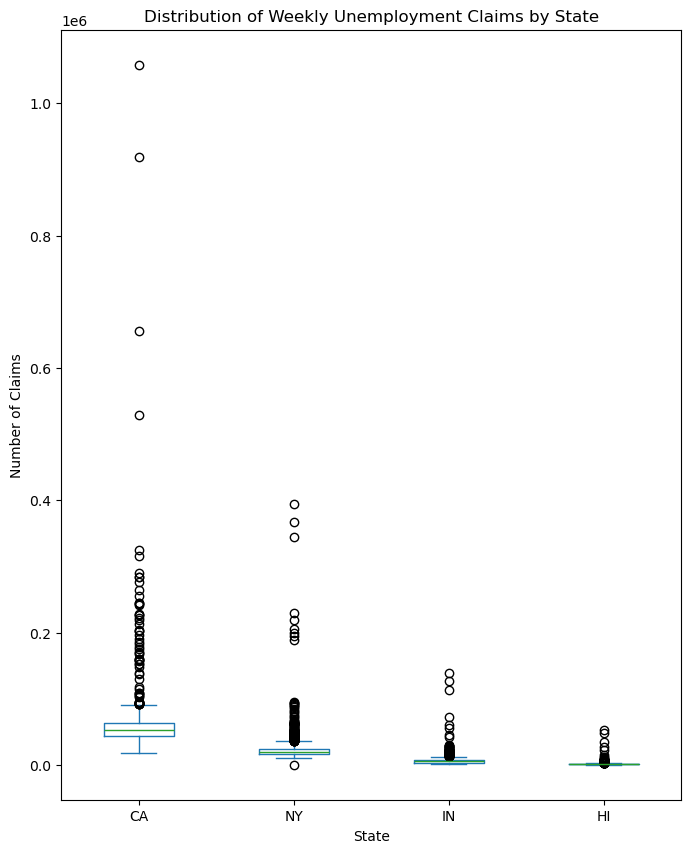

In [8]:
## Setting up a basic dataframe object to work with
df_all = pd.concat([claims_dfs[code]["Claims"] for code in datasets],axis=1)
df_all.columns = ["CA", "NY", "IN", "HI"]

## Boxplot for distribution of weekly unemployment claims per state
df_all.plot(kind="box", figsize=(8,10))
plt.title("Distribution of Weekly Unemployment Claims by State")
plt.ylabel("Number of Claims")
plt.xlabel("State")
plt.show()

The summary statistics for `df_all` show the distribution of weekly unemployment claims by state. California has the highest median and maximum number of unemployment claims, and also has the widest spread and the highest outliers. But California's large number of unemployment claims makes it difficult to see the plots for other graphs. Let's graph these plots on a log scale, as seen below.

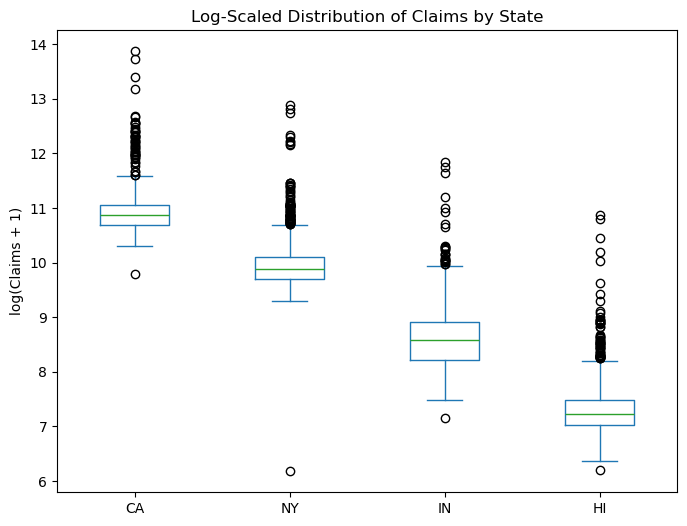

In [9]:
## Log scale
df_all_log = np.log1p(df_all)
df_all_log.plot(kind="box", figsize=(8,6))

## Setting up plot
plt.title("Log-Scaled Distribution of Claims by State")
plt.ylabel("log(Claims + 1)")
plt.show()

California dominates due to much higher absolute claim counts, but the log scale reveals underlying distribution patterns more clearly. Some states show slightly wider boxes and longer whiskers, showing greater relative volatility in claims. Outliers still remain after log-scaling, highlighting extreme economic shocks on a macro scale (ex. COVID-19 pandemic).

In [10]:
df_all.dtypes

CA    float64
NY    float64
IN    float64
HI    float64
dtype: object

The number of claims for each state is a float, which means it can be easily manipulated for computations.

## **7. Producing Summary Statistics**

Here, we work to produce summary statistics, those of which are useful as they provide us with a scope of the basic scale of claims existing in each state. Prior to any analysis, we naturally expect states like California and New York to have much larger claims as compared to Hawaii and Indiana, as the latter states have much smaller labor markets. 

**Code cell purpose:** Below, we have a cell which calculates relevant summary statistics per state, including spread, raw missing counts, etc.  This matters because these statistics provide a compact comparison of each state's claims scale and volatility, which helps interpret forecast RMSE later.

In [11]:
## Simply getting summary statistics
summary_stats = (
    combined_claims
    .groupby("State")
    .agg(
        observations=("Claims", "size"),
        raw_missing_claims=("Claims_Was_Missing", "sum"),
        mean_claims=("Claims", "mean"),
        median_claims=("Claims", "median"),
        sd_claims=("Claims", "std"),
        min_claims=("Claims", "min"),
        p25_claims=("Claims", lambda x: x.quantile(0.25)),
        p75_claims=("Claims", lambda x: x.quantile(0.75)),
        max_claims=("Claims", "max")
    )
    .reset_index()
)

## Adding a coefficient of variation to compare the volatility across differently sized states
summary_stats["cv_claims"] = summary_stats["sd_claims"] / summary_stats["mean_claims"]

## Displaying
display(summary_stats.round(2))

,State,observations,raw_missing_claims,mean_claims,median_claims,sd_claims,min_claims,p25_claims,p75_claims,max_claims,cv_claims
0,California,2097,5,"58,606.31","52,384.00","42,137.74","18,046.00","44,001.00","63,122.00","1,058,325.00",0.72
1,Hawaii,2141,48,"1,673.52","1,385.00","2,028.86",495.00,"1,118.00","1,790.00","53,102.00",1.21
2,Indiana,2096,0,"6,547.56","5,379.00","6,415.86","1,279.00","3,685.75","7,384.50","139,174.00",0.98
3,New York,2096,0,"22,871.85","19,493.50","19,048.16",481.00,"16,377.50","24,292.75","394,701.00",0.83


## **8. Analyzing Annual Trends**

Here, we look at an annual summary for each of the state's claims, that of which provides good insight into how the average and maximum claims have changed progressively. What is most helpful to pull from these results include data for years close to recession periods/the COVID spike, helping us with later model design/validation below.

**Code cell purpose:** Below, we have a cell which summarizes the claims data per year for each state, helping reveal certain long-term trends.  This matters because annual aggregation makes long-run trends and major macro shocks easier to see than weekly values alone.

In [12]:
## Generating the annual summary
annual_summary = (
    combined_claims
    .groupby(["State", "Year"])
    .agg(
        avg_claims=("Claims", "mean"),
        total_claims=("Claims", "sum"),
        max_claims=("Claims", "max"),
        weeks_observed=("Claims", "size")
    )
    .reset_index()
)

## Displaying most recent years first as these are the most relevant for forecasting
display(annual_summary.sort_values(["State", "Year"], ascending=[True, False]).head(20).round(2))

## Also displaying the COVID peak year directly for report-writing and insight purposes
covid_year_summary = annual_summary.loc[annual_summary["Year"].between(2019, 2021)]
display(covid_year_summary.sort_values(["State", "Year"]).round(2))

,State,Year,avg_claims,total_claims,max_claims,weeks_observed
40,California,2026,"43,231.33","648,470.00","55,731.00",15
39,California,2025,"43,392.56","2,256,413.00","59,969.00",52
38,California,2024,"43,437.54","2,258,752.00","52,368.00",52
37,California,2023,"44,741.08","2,326,536.00","63,697.00",52
36,California,2022,"43,004.45","2,279,236.00","62,274.00",53
35,California,2021,"76,080.29","3,956,175.00","182,625.00",52
34,California,2020,"221,880.15","11,537,768.00","1,058,325.00",52
33,California,2019,"40,371.40","2,099,313.00","56,886.00",52
32,California,2018,"40,750.71","2,119,037.00","58,962.00",52
31,California,2017,"43,307.54","2,251,992.00","61,914.00",52


,State,Year,avg_claims,total_claims,max_claims,weeks_observed
33,California,2019,"40,371.40","2,099,313.00","56,886.00",52
34,California,2020,"221,880.15","11,537,768.00","1,058,325.00",52
35,California,2021,"76,080.29","3,956,175.00","182,625.00",52
75,Hawaii,2019,"1,187.52","61,751.00","1,903.00",52
76,Hawaii,2020,"8,376.58","435,582.00","53,102.00",52
77,Hawaii,2021,"2,694.88","140,134.00","5,598.00",52
116,Indiana,2019,"2,635.83","137,063.00","4,835.00",52
117,Indiana,2020,"24,371.67","1,267,327.00","139,174.00",52
118,Indiana,2021,"7,606.96","395,562.00","17,724.00",52
157,New York,2019,"15,844.73","823,926.00","45,065.00",52


## **9. Generating Time-Series Plots by State**

Here, we generate time-series plots for each state, with the first plot showcasing each state separately (do not want California's large scale taking over visualization of smaller states). The second plot has all states overlaid in levels, allowing us to compare timing of spikes.

**Code cell purpose:** Here, we have both separated and overlaid visualizations of time siries for the states. Directly below is separate. This matters because separate plots keep smaller states readable while still showing each state's overall time-series pattern.

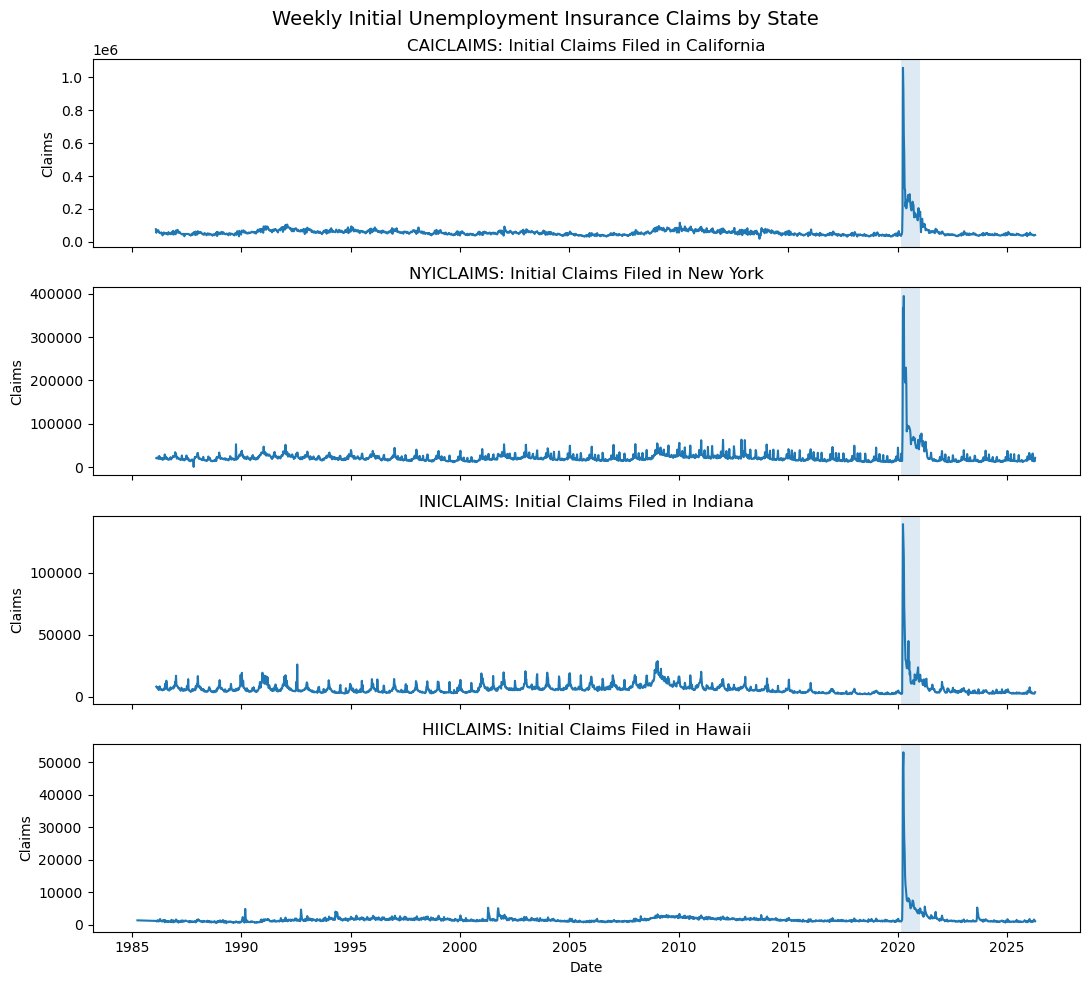

In [13]:
## Setting figure specifications
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)

## Generating the figures
for ax, code in zip(axes, datasets):
    df = claims_dfs[code]
    ax.plot(df["Date"], df["Claims"])
    ax.set_title(f"{code}: Initial Claims Filed in {state_names[code]}")
    ax.set_ylabel("Claims")
    
    ## Marking the early COVID period as it is the largest structural break in the series, important!
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-01-01"), alpha=0.15)

axes[-1].set_xlabel("Date")
fig.suptitle("Weekly Initial Unemployment Insurance Claims by State", fontsize=14)
plt.tight_layout()
plt.show();


**Code cell purpose:** Directly below is overlaid.
This matters because the overlaid plot shows the relative timing of spikes across states, even though raw levels are not directly comparable.

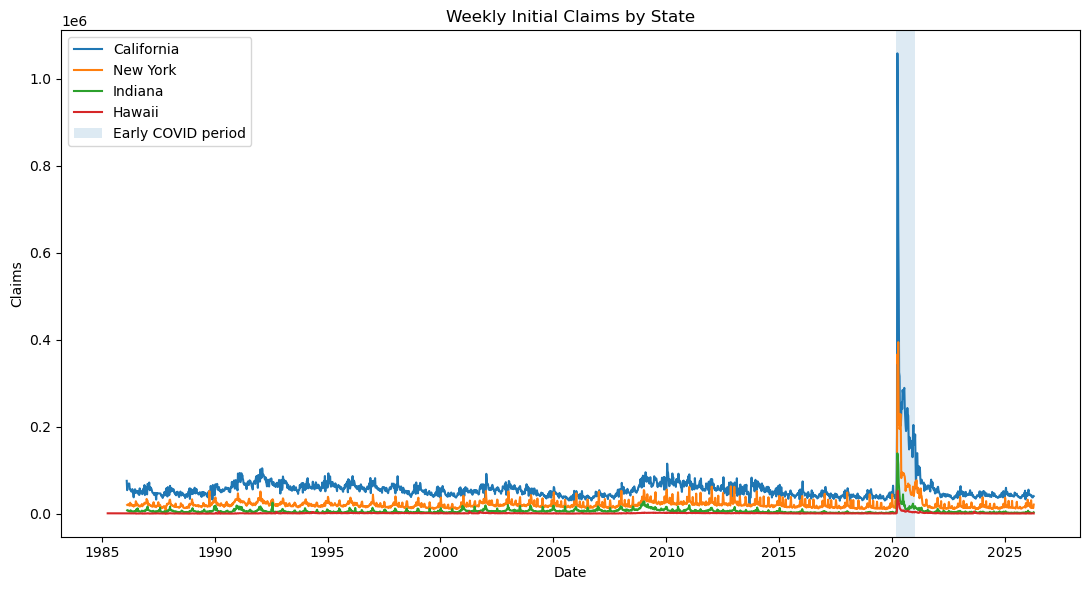

In [14]:
## Setting figure specifications
fig, ax = plt.subplots(figsize=(11, 6))

## Generating the figures
for code in datasets:
    df = claims_dfs[code]
    ax.plot(df["Date"], df["Claims"], label=state_names[code])

ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-01-01"), alpha=0.15, label="Early COVID period")
ax.set_xlabel("Date")
ax.set_ylabel("Claims")
ax.set_title("Weekly Initial Claims by State")
ax.legend()
plt.tight_layout()
plt.show();


**Code cell purpose:** Here, we have a visualization in which we can clearly see times of recessions shaded. This matters because recession shading connects claims spikes to national macroeconomic downturns and gives context for later forecast difficulty.

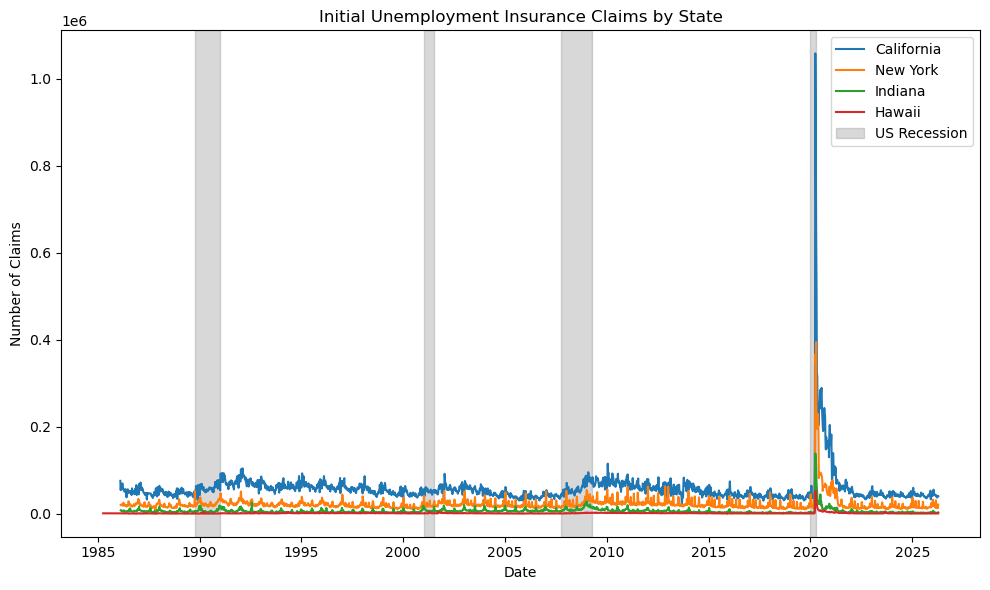

In [15]:
## Looking at distinct visualization of recessions shaded

recessions = pd.read_csv("Data/JHDUSRGDPBR.csv")
recessions["observation_date"] = pd.to_datetime(recessions["observation_date"])

## Setting the recession dataset to use dates as its index
recessions = recessions.set_index("observation_date")

## Getting the full date range from the claims data using the Date column, not the row index
start_date = min(claims_dfs[code]["Date"].min() for code in datasets)
end_date = max(claims_dfs[code]["Date"].max() for code in datasets)

## Keeping only recession data within the claims sample period
recessions = recessions.loc[start_date:end_date]

fig, ax = plt.subplots(figsize=(10, 6))

## Plotting weekly initial claims for each state
for code in datasets:
    df = claims_dfs[code]
    ax.plot(df["Date"], df["Claims"], label=state_names[code])

## Shading weeks/months classified as US recession periods
ax.fill_between(
    recessions.index,
    0,
    1,
    where=recessions["JHDUSRGDPBR"] == 1,
    color="gray",
    alpha=0.3,
    transform=ax.get_xaxis_transform(),
    label="US Recession"
)

## Formatting the figure
ax.set_title("Initial Unemployment Insurance Claims by State")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Claims")
ax.legend()
plt.tight_layout()
plt.show()

## **10. Having Indexed Comparison Across States**

Each of the states has varied population sizes which are not directly comparable. Therefore, simply comparing raw claims would not be beneficial. Instead, we have an indexed plot which sets each state's first observed week equivalent to 100, such that the graph makes comparisons of relative changes rather than raw levels.

**Code cell purpose:** Below, we have a cell generating indexed claims such that states with varied baseline levels can still be directly compared on similar scales.  This matters because indexing makes the states comparable by relative change rather than by raw population-size differences.

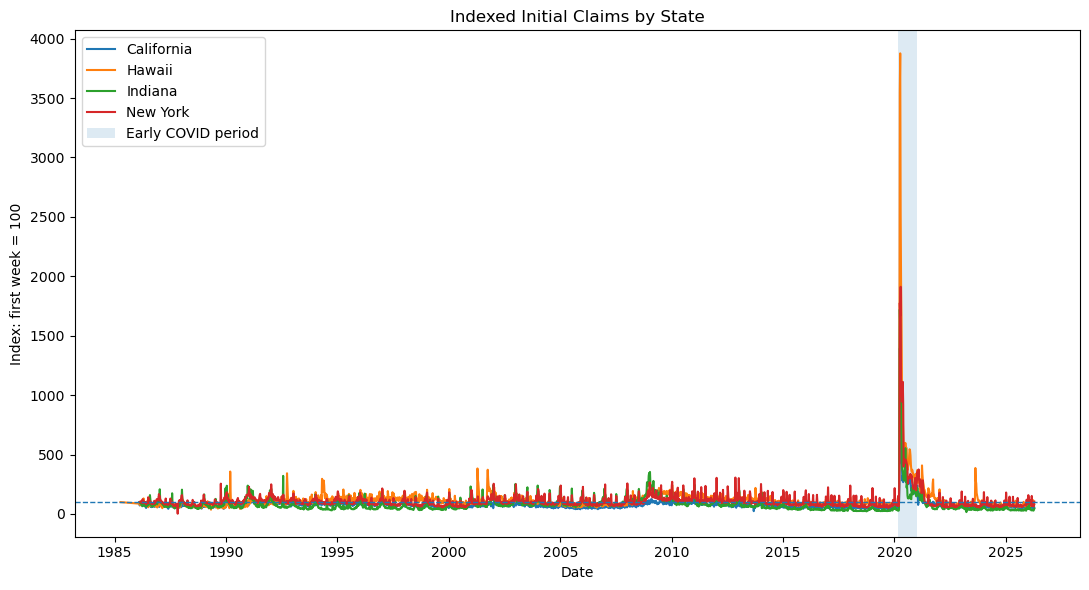

In [16]:
## Generating the indexed claims below
indexed_claims = combined_claims.copy()
indexed_claims["Claims_Index"] = (
    indexed_claims
    .groupby("State")["Claims"]
    .transform(lambda x: 100 * x / x.iloc[0])
)

## Setting up figure
fig, ax = plt.subplots(figsize=(11, 6))

## Actually plotting!
for state, df in indexed_claims.groupby("State"):
    ax.plot(df["Date"], df["Claims_Index"], label=state)

ax.axhline(100, linestyle="--", linewidth=1)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-01-01"), alpha=0.15, label="Early COVID period")
ax.set_xlabel("Date")
ax.set_ylabel("Index: first week = 100")
ax.set_title("Indexed Initial Claims by State")
ax.legend()
plt.tight_layout()
plt.show();


## **11. Reviewing the Distribution and Checking Outliers**

Here, we felt it useful to have histograms generated that let us see the distribution of weekly claims for each state. In doing so, we can see things like heavy large right tails, something that checks out with basic sanity as unemployment claims tend to spike during recessions and times of stress like COVID (so occasionally we see singular major rises). Understanding these spikes is important so we are not confused later when modeling.

**Code cell purpose:** Below, the cell generates visualizations for each state's claims distribution, showcasing potential skews.
This matters because distributional skew and extreme observations affect model fit, residual behavior, and forecast-error interpretation.

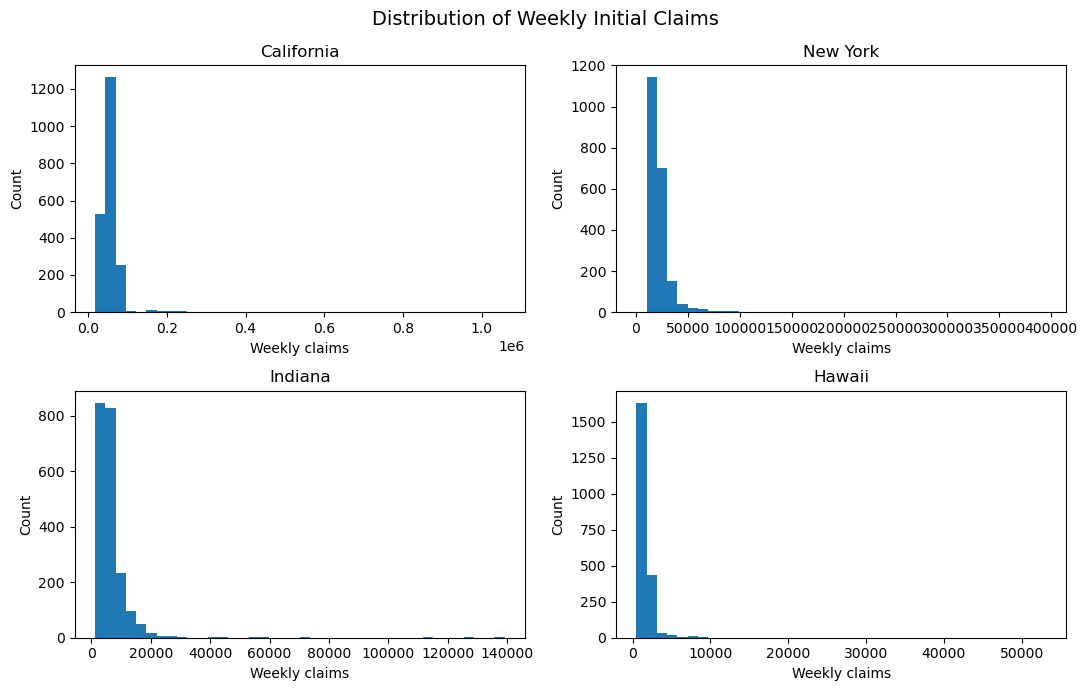

In [17]:
## Setting up the figure
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

## Generating plot
for ax, code in zip(axes, datasets):
    df = claims_dfs[code]
    ax.hist(df["Claims"], bins=40)
    ax.set_title(state_names[code])
    ax.set_xlabel("Weekly claims")
    ax.set_ylabel("Count")

fig.suptitle("Distribution of Weekly Initial Claims", fontsize=14)
plt.tight_layout()
plt.show();


## **12. Looking Into the Largest Weekly Claims Observations**

As the above distributions have a pretty distinct right-skew, we felt it important to directly identify the weeks with biggest claims for each state. Again, such rows are not problem rows or errors, per say, instead corresponding to things like recessions or COVID shocks. Again, this helps us begin thinking about how to approach structural breaks.

**Code cell purpose:** Cell below works to identify largest weekly claims observations in each state, separation between data errors from actual shocks.  This matters because the largest observations are usually substantive economic shocks, especially COVID, rather than simple data mistakes.

In [18]:
## Determining largest claims
top_claim_weeks = (
    combined_claims
    .sort_values("Claims", ascending=False)
    .loc[:, ["State", "StateCode", "Date", "Claims", "Year"]]
    .head(50)
)

## Displaying, and seeing that years tend to be COVID times and other recession periods!
display(top_claim_weeks)

,State,StateCode,Date,Claims,Year
1781,California,CAICLAIMS,2020-03-28,"1,058,325.00",2020
1782,California,CAICLAIMS,2020-04-04,"918,814.00",2020
1783,California,CAICLAIMS,2020-04-11,"655,472.00",2020
1784,California,CAICLAIMS,2020-04-18,"528,360.00",2020
3879,New York,NYICLAIMS,2020-04-11,"394,701.00",2020
3877,New York,NYICLAIMS,2020-03-28,"366,595.00",2020
3878,New York,NYICLAIMS,2020-04-04,"344,451.00",2020
1785,California,CAICLAIMS,2020-04-25,"325,343.00",2020
1786,California,CAICLAIMS,2020-05-02,"316,257.00",2020
1797,California,CAICLAIMS,2020-07-18,"289,594.00",2020


## **13. Looking at Rolling-Average Trends**

By looking at rolling average over 52 weeks rather than individual gaps, we can smooth out minor moments of volatility and instead look at where there are major changes in the long-run. Mainly for building understanding of the data we have prior to intense forecasting.

**Code cell purpose:** Cell below computes and plots 52-week rolling averages for each state, smoothing weekly volatility prior to modeling.
This matters because rolling averages reveal medium-run claims patterns while reducing week-to-week noise before formal forecasting.

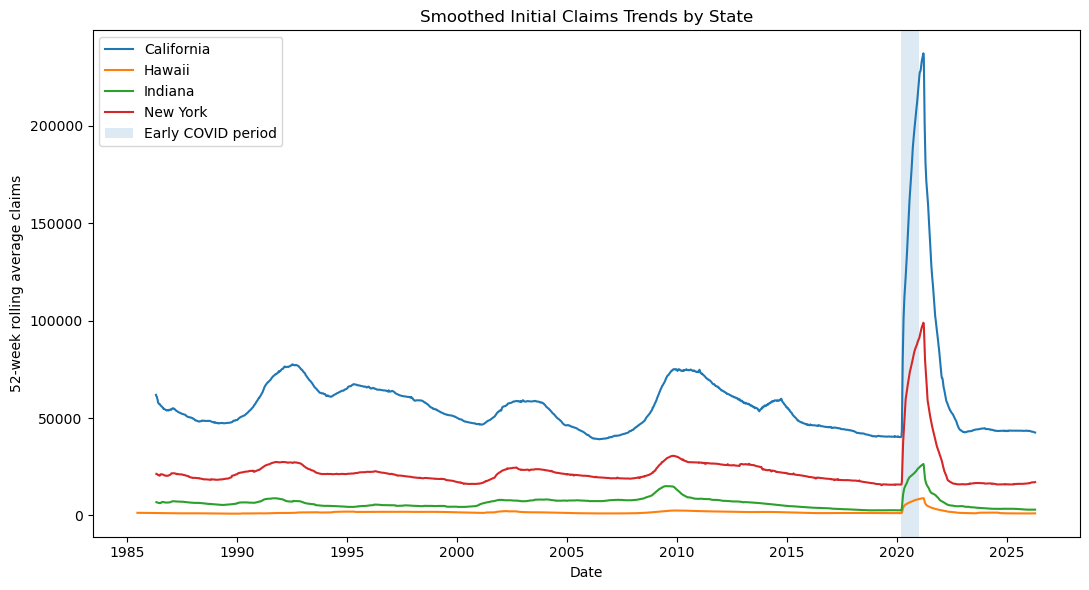

In [19]:
## Generating rolling claims
rolling_claims = combined_claims.sort_values(["State", "Date"]).copy()
rolling_claims["Claims_52wk_MA"] = (
    rolling_claims
    .groupby("State")["Claims"]
    .transform(lambda x: x.rolling(window=52, min_periods=12).mean())
)

## Setting up figure
fig, ax = plt.subplots(figsize=(11, 6))

## Plotting!
for state, df in rolling_claims.groupby("State"):
    ax.plot(df["Date"], df["Claims_52wk_MA"], label=state)

ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-01-01"), alpha=0.15, label="Early COVID period")
ax.set_xlabel("Date")
ax.set_ylabel("52-week rolling average claims")
ax.set_title("Smoothed Initial Claims Trends by State")
ax.legend()
plt.tight_layout()
plt.show();


## **14. Major Takeaways to Carry Forward**

- We see that there are some missing values for states like Hawaii which needed to be interpolated. Details about process/logic in report

- No issue of duplicate, negative, or oddly-gapped claims data

- Clear difference in the level of claims for each state, matches with basic logic of larger states with larger labor markets have larger claims levels

- Understanding of spikes during shocks like COVID, periods of recession, etc. do appear quite clearly, basic logic checks out here

# **CAICLAIMS Model Testing - Determining Model Efficacy Prior to Scaling**

This entire section works with California data as the initial example for forecasting, prior to scaling up to all of the four states we have. We utilized the final two years of data as a test set, fitting a basic ARIMA baseline, and afterwards adding SARIMAX specifications with Fourier seasonality and COVID indicators to deal with the structural break. RMSE is utilized as a measure of out-of-sample prediction accuracy, and we additionally have AIC/BIC as model-selection diagnostics. 

## **1. ARIMA Baseline Model**

**Code cell purpose:** The cell below generates the California modeling series, additionally defining the training and two-year holdout test periods. This matters because the same two-year holdout logic becomes the evaluation standard for comparing forecasts out of sample.

Training period: 1986-02-08 to 2024-04-13 (1,993 weeks)
Testing period: 2024-04-20 to 2026-04-11 (104 weeks)


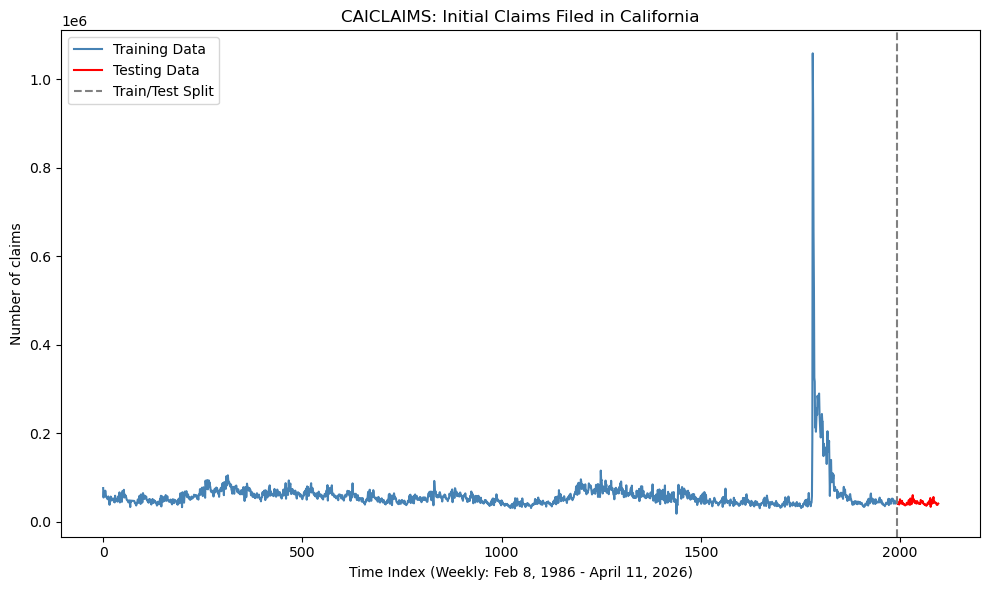

In [20]:
## Choosing just California
y_CA = claims_dfs["CAICLAIMS"]["Claims"].reset_index(drop=True)
date_CA = claims_dfs["CAICLAIMS"]["Date"].reset_index(drop=True)

## Separating the test set
test_horizon = 104  ## final 2 years
train_end = len(y_CA) - test_horizon

## Numeric time indexes are kept because the original modeling code was built around them
ttrain = np.arange(train_end)
ttest = np.arange(train_end, len(y_CA))
tpred = np.arange(train_end, len(y_CA) + test_horizon)  ## testing period plus 2-year future forecast

## Training modeling
ytrain_CA = y_CA.iloc[:train_end]
ytest_CA = y_CA.iloc[train_end:]

train_start_date = date_CA.iloc[0]
train_end_date = date_CA.iloc[train_end - 1]
test_start_date = date_CA.iloc[train_end]
test_end_date = date_CA.iloc[-1]

## Setting up the figures
print(f"Training period: {train_start_date.date()} to {train_end_date.date()} ({len(ytrain_CA):,} weeks)")
print(f"Testing period: {test_start_date.date()} to {test_end_date.date()} ({len(ytest_CA):,} weeks)")

plt.figure(figsize=(10, 6))
plt.plot(ttrain, ytrain_CA, label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Testing Data", color="red")
plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.title("CAICLAIMS: Initial Claims Filed in California")
plt.xlabel("Time Index (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();

### **Analysis of the Training Data Time Series**

**Code cell purpose:** Below, we have a cell which plots ACF and PACF of training level series, allowing us to inspect persistence prior to actual ARIMA modeling. This matters because ACF/PACF plots help motivate candidate AR and MA orders before running a formal grid search.

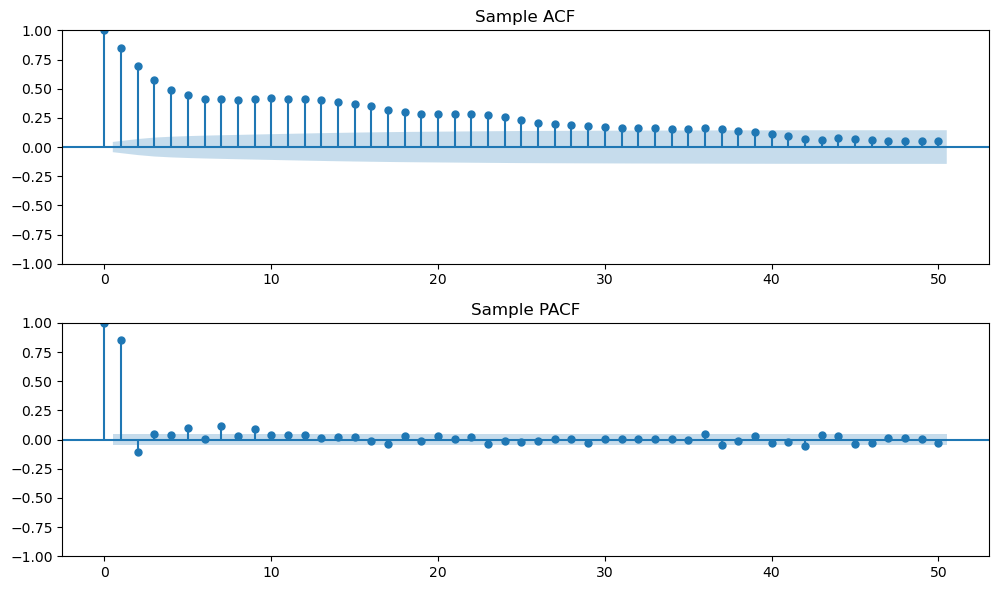

In [21]:
## Setting p_max
p_max = 50

## ACF/PACF on the level series helps show persistence before differencing
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(ytrain_CA.dropna(), lags=p_max, ax=ax1, title="Sample ACF")
plot_pacf(ytrain_CA.dropna(), lags=p_max, ax=ax2, title="Sample PACF")
plt.tight_layout()
plt.show();

**Code cell purpose:** Cell below completes differencing of training series and plots weekly changes, allowing us to asses whether differencing actualy improves stationarity.  This matters because differencing is one of the main ways ARIMA handles non-stationary claims levels.

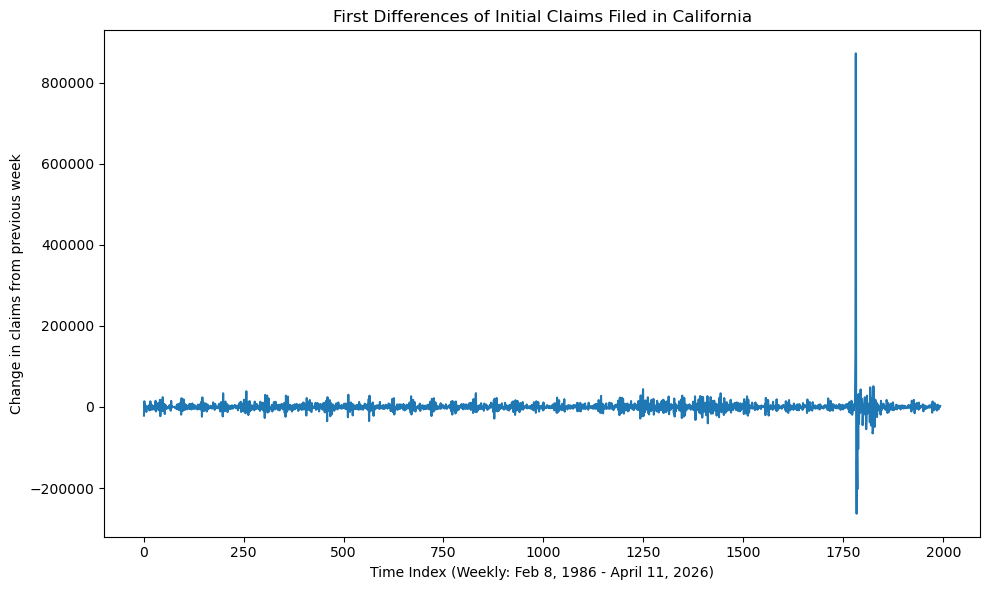

In [22]:
## Differenced training set
ytrain_CA_diff = ytrain_CA.diff()

## First differences removes much of the slow-moving trend and help ARIMA with non-stationarity!
plt.figure(figsize=(10,6))
plt.plot(ytrain_CA_diff.dropna())
plt.xlabel("Time Index (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Change in claims from previous week")
plt.title("First Differences of Initial Claims Filed in California")
plt.tight_layout()
plt.show();

**Code cell purpose:** Cell below plots the ACF/PACF of differenced series, again for ARIMA order choice logic.  This matters because the differenced ACF/PACF gives a cleaner view of short-run dependence after removing slow-moving level behavior.

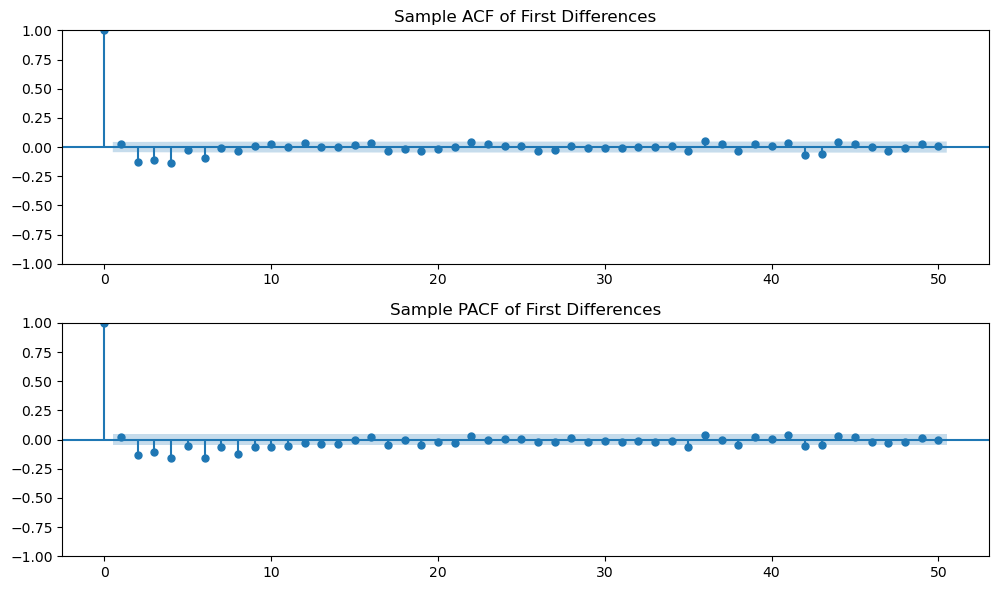

In [23]:
## Setting p_max
p_max = 50

## ACF/PACF after the differencing gives us a practical guide for candidate AR and MA orders
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(ytrain_CA_diff.dropna(), lags=p_max, ax=ax1, title="Sample ACF of First Differences")
plot_pacf(ytrain_CA_diff.dropna(), lags=p_max, ax=ax2, title="Sample PACF of First Differences")
plt.tight_layout()
plt.show();

### **Checking Stationarity**

Utilizing the ADF to formally check for a unit root (which would make our time series non-stationary). Basically, this is to inform our decision to potentially include the parameter of `d=1` in later ARIMA/SARIMAX grid work when we have a very prevalent level series.

**Code cell purpose:** Cell below runs ADF tests on level and differenced training series, want to justify choice of differencing.  This matters because the ADF results provide a formal check supporting whether the ARIMA/SARIMAX models should include differencing.

In [24]:
## Brief function for ADF work
def adf_summary(series, label):
    clean_series = pd.Series(series).dropna()
    stat, pvalue, used_lag, nobs, crit_vals, _ = adfuller(clean_series, autolag="AIC")
    return {
        "series": label, "adf_statistic": stat, "p_value": pvalue,
        "used_lag": used_lag, "n_obs": nobs,
        "critical_value_5pct": crit_vals["5%"]
    }

## Getting the ADF results
adf_results = pd.DataFrame([
    adf_summary(ytrain_CA, "CA claims, levels"),
    adf_summary(ytrain_CA_diff, "CA claims, first differences")
])

display(adf_results.round(4))


,series,adf_statistic,p_value,used_lag,n_obs,critical_value_5pct
0,"CA claims, levels",-6.15,0.00,11,1981,-2.86
1,"CA claims, first differences",-14.23,0.00,18,1973,-2.86


### **Parameter Selection (Grid Search)**

**Code cell purpose:** Below cell works to define ARIMA grid-search helper, function is brief and only goal is to return AIC, BIC, and holdout RMSE here. This matters because the helper standardizes how every ARIMA candidate is scored using train-fit diagnostics and holdout RMSE.

In [25]:
## Setting parameters
pmax, dmax, qmax = 8, 1, 6

## Defining the ARIMA fitting function with parameters
def fit_arima(params):
    p, d, q = map(int, params)
    try:
        model = ARIMA(ytrain_CA, order=(p, d, q)).fit()
        yhat = model.get_forecast(steps=len(ytest_CA)).predicted_mean
        yhat.index = ytest_CA.index
        rmse = np.sqrt(mean_squared_error(ytest_CA, yhat))
        return {"p": p, "d": d, "q": q, "AIC": model.aic, "BIC": model.bic, "RMSE": rmse}
    except Exception:
        return None


**Code cell purpose:** Cell below actually runs/loads ARIMA grid search, gives best candidate models based on the holdout RMSE.  This matters because caching prevents the same expensive model grid from being refit every time the notebook is rerun.

In [26]:
## Setting distinct path
cache_path_arima = "CAICLAIMS_Model_Cache/arima_grid_results_CAICLAIMS.csv"

## Building grid for parameter
param_grid = list(itertools.product(
    range(pmax + 1),
    range(dmax + 1),
    range(qmax + 1)
))

## Necessary columns
required_arima_cols = {"p", "d", "q", "AIC", "BIC", "RMSE"}

## Working through the process! Detailed steps below
if os.path.exists(cache_path_arima):
    print(f"Loading cached ARIMA grid search results from {cache_path_arima}")
    results_arima_df = pd.read_csv(cache_path_arima)

    ## Re-run if the cache is not in the expected format
    if not required_arima_cols.issubset(results_arima_df.columns):
        print("The cached ARIMA results are missing required columns, so the grid search needs to be run again.")
        results_arima_df = pd.DataFrame()

else:
    results_arima_df = pd.DataFrame()

if results_arima_df.empty:
    print("Running ARIMA grid search!")

    results_arima = Parallel(n_jobs=-1, verbose=10)(
        delayed(fit_arima)(params) for params in param_grid
    )

    results_arima = [r for r in results_arima if r is not None]
    results_arima_df = pd.DataFrame(results_arima)

    if results_arima_df.empty:
        raise ValueError("ARIMA grid search failed, meaning no models were successfully fit!")

    results_arima_df.to_csv(cache_path_arima, index=False)
    print(f"Saved ARIMA grid search results to {cache_path_arima}")

## Showing the best few models by holdout RMSE for transparency
display(results_arima_df.sort_values("RMSE").head(10).round(3))

Loading cached ARIMA grid search results from CAICLAIMS_Model_Cache/arima_grid_results_CAICLAIMS.csv


,p,d,q,AIC,BIC,RMSE
119,8,1,0,"45,577.51","45,627.88","4,599.13"
63,4,1,0,"45,662.47","45,690.45","4,602.98"
77,5,1,0,"45,658.34","45,691.92","4,621.72"
105,7,1,0,"45,604.59","45,649.36","4,635.10"
91,6,1,0,"45,609.98","45,649.16","4,664.12"
10,0,1,3,"45,644.79","45,667.18","4,681.73"
9,0,1,2,"45,710.97","45,727.76","4,682.99"
49,3,1,0,"45,709.97","45,732.36","4,688.87"
11,0,1,4,"45,560.18","45,588.16","4,756.92"
37,2,1,2,"45,571.39","45,599.37","4,764.09"


### **Determining the Best Models by Evaluation Metrics**

**Code cell purpose:** Cell below extracts the best ARIMA specifications as according to our three desired metrics of AIC, BIC, and holdout RMSE. This matters because the notebook compares selection by fit diagnostics against selection by out-of-sample forecast accuracy.

In [27]:
## Getting best values
best_aic = results_arima_df.loc[results_arima_df["AIC"].idxmin()]
best_bic = results_arima_df.loc[results_arima_df["BIC"].idxmin()]
best_rmse = results_arima_df.loc[results_arima_df["RMSE"].idxmin()]

## Printing it out legibly below
print(
    f"Best model by AIC: ARIMA({int(best_aic['p'])}, {int(best_aic['d'])}, {int(best_aic['q'])}), "
    f"AIC: {best_aic['AIC']:.3f}, BIC: {best_aic['BIC']:.3f}, RMSE: {best_aic['RMSE']:.3f}"
)

print(
    f"Best model by BIC: ARIMA({int(best_bic['p'])}, {int(best_bic['d'])}, {int(best_bic['q'])}), "
    f"AIC: {best_bic['AIC']:.3f}, BIC: {best_bic['BIC']:.3f}, RMSE: {best_bic['RMSE']:.3f}"
)

print(
    f"Best model by RMSE: ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}), "
    f"AIC: {best_rmse['AIC']:.3f}, BIC: {best_rmse['BIC']:.3f}, RMSE: {best_rmse['RMSE']:.3f}"
)

Best model by AIC: ARIMA(6, 0, 4), AIC: 45543.513, BIC: 45610.682, RMSE: 14433.620
Best model by BIC: ARIMA(0, 1, 6), AIC: 45545.010, BIC: 45584.189, RMSE: 4809.309
Best model by RMSE: ARIMA(8, 1, 0), AIC: 45577.506, BIC: 45627.878, RMSE: 4599.134


**Code cell purpose:** Cell below completes fitting of ARIMA model selected using AIC, prints out summary. This matters because the AIC-selected model summary lets us inspect the model that is preferred by in-sample information criteria.

In [28]:
## Getting the AIC summary results!
best_aic_model = ARIMA(
    ytrain_CA,
    order=(int(best_aic["p"]), int(best_aic["d"]), int(best_aic["q"]))
).fit()

print(best_aic_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:                 ARIMA(6, 0, 4)   Log Likelihood              -22759.769
Date:                Sun, 03 May 2026   AIC                          45543.538
Time:                        02:52:13   BIC                          45610.707
Sample:                             0   HQIC                         45568.205
                               - 1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.942e+04   1.19e+04      5.000      0.000    3.61e+04    8.27e+04
ar.L1          0.4565      0.183      2.498      0.012       0.098       0.815
ar.L2          1.5475      0.060     25.915      0.0

**Code cell purpose:** Cell below completes fitting of ARIMA model selected using BIC, prints out summary.
This matters because the BIC-selected model summary provides a more parsimonious benchmark for comparison.

In [29]:
## Getting the BIC summary results!
best_bic_model = ARIMA(
    ytrain_CA,
    order=(int(best_bic["p"]), int(best_bic["d"]), int(best_bic["q"]))
).fit()

print(best_bic_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:                 ARIMA(0, 1, 6)   Log Likelihood              -22765.505
Date:                Sun, 03 May 2026   AIC                          45545.010
Time:                        02:52:14   BIC                          45584.189
Sample:                             0   HQIC                         45559.399
                               - 1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0635      0.005    -13.003      0.000      -0.073      -0.054
ma.L2         -0.2219      0.012    -17.911      0.000      -0.246      -0.198
ma.L3         -0.1540      0.029     -5.395      0.0

**Code cell purpose.** Cell below completes fitting of ARIMA model selected using holdout RMSE, prints out summary.
This matters because the RMSE-selected model is the direct forecasting benchmark used in later plots and tables.

In [30]:
## Getting the RMSE summary results!
best_rmse_model = ARIMA(
    ytrain_CA,
    order=(int(best_rmse["p"]), int(best_rmse["d"]), int(best_rmse["q"]))
).fit()

print(best_rmse_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:                 ARIMA(8, 1, 0)   Log Likelihood              -22779.753
Date:                Sun, 03 May 2026   AIC                          45577.506
Time:                        02:52:14   BIC                          45627.878
Sample:                             0   HQIC                         45596.005
                               - 1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0415      0.004    -10.140      0.000      -0.050      -0.033
ar.L2         -0.2007      0.010    -20.251      0.000      -0.220      -0.181
ar.L3         -0.1481      0.042     -3.536      0.0

### **Plotted ARIMA Predictions**

**Code cell purpose:** Cell below performs forecasting with selected ARIMA models, additionally plotting their predictions against holdout data.  This matters because plotting forecasts against the holdout set shows not only the RMSE value but also when the model misses most visibly.

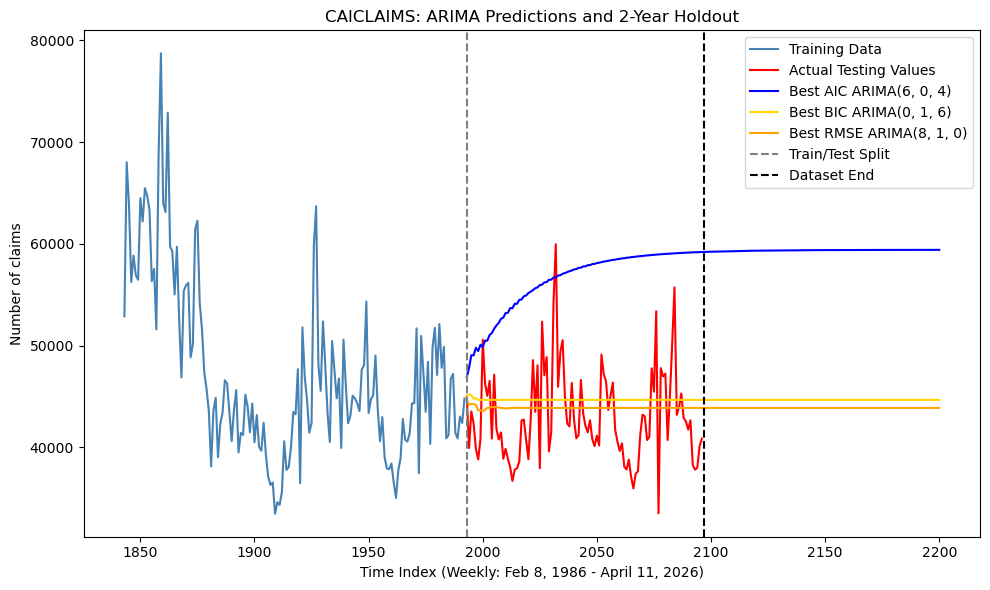

Root Mean Squared Error of Best AIC ARIMA(6, 0, 4) Model: 14423.869
Root Mean Squared Error of Best BIC ARIMA(0, 1, 6) Model: 4809.309
Root Mean Squared Error of Best RMSE ARIMA(8, 1, 0) Model: 4599.134


In [31]:
## Best results from AIC
best_aic_fcast = best_aic_model.get_prediction(start=train_end, end=len(y_CA) + test_horizon - 1)
best_aic_yhat = best_aic_fcast.predicted_mean
best_aic_rmse = np.sqrt(mean_squared_error(ytest_CA, best_aic_yhat.iloc[:len(ytest_CA)]))

## Best results from BIC
best_bic_fcast = best_bic_model.get_prediction(start=train_end, end=len(y_CA) + test_horizon - 1)
best_bic_yhat = best_bic_fcast.predicted_mean
best_bic_rmse = np.sqrt(mean_squared_error(ytest_CA, best_bic_yhat.iloc[:len(ytest_CA)]))

## Best results from holdout RMSE
best_rmse_fcast = best_rmse_model.get_prediction(start=train_end, end=len(y_CA) + test_horizon - 1)
best_rmse_yhat = best_rmse_fcast.predicted_mean
best_rmse_rmse = np.sqrt(mean_squared_error(ytest_CA, best_rmse_yhat.iloc[:len(ytest_CA)]))

## Getting the figures/plots set up
plt.figure(figsize=(10,6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA.iloc[(train_end - 150):], color="steelblue", label="Training Data")
plt.plot(ttest, ytest_CA, color="red", label="Actual Testing Values")

plt.plot(tpred, best_aic_yhat, color="blue", 
         label=f"Best AIC ARIMA({int(best_aic['p'])}, {int(best_aic['d'])}, {int(best_aic['q'])})")
plt.plot(tpred, best_bic_yhat, color="gold", 
         label=f"Best BIC ARIMA({int(best_bic['p'])}, {int(best_bic['d'])}, {int(best_bic['q'])})")
plt.plot(tpred, best_rmse_yhat, color="orange", 
         label=f"Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])})")

plt.axvline(x=train_end, color="grey", linestyle="--", label="Train/Test Split")
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End")

plt.xlabel("Time Index (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.title("CAICLAIMS: ARIMA Predictions and 2-Year Holdout")
plt.legend(); plt.tight_layout(); plt.show();

print(f"Root Mean Squared Error of Best AIC ARIMA({int(best_aic['p'])}, {int(best_aic['d'])}, {int(best_aic['q'])}) Model: {best_aic_rmse:.3f}")
print(f"Root Mean Squared Error of Best BIC ARIMA({int(best_bic['p'])}, {int(best_bic['d'])}, {int(best_bic['q'])}) Model: {best_bic_rmse:.3f}")
print(f"Root Mean Squared Error of Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {best_rmse_rmse:.3f}")

## **2. SARIMAX with Fourier Frequencies, Before/After COVID Dummy**

**Code cell purpose:** Cell below plots entire California split between train and test, allows forecasting setup to be clear visually.  This matters because the visual split confirms which observations are used for estimation versus out-of-sample evaluation.

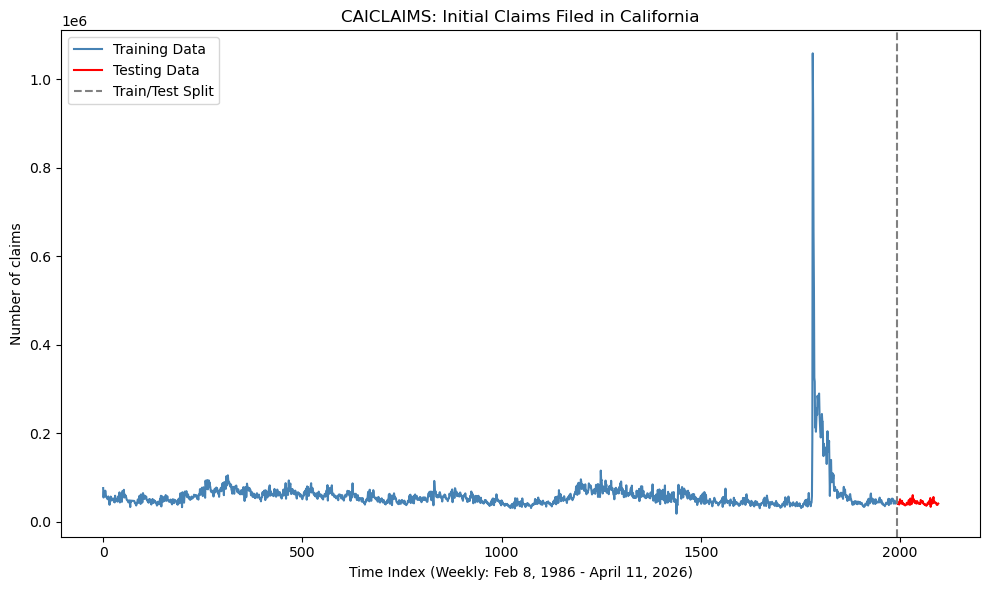

In [32]:
## Plotting everything!
plt.figure(figsize=(10, 6))
plt.plot(ttrain, ytrain_CA, label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Testing Data", color="red")
plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.title("CAICLAIMS: Initial Claims Filed in California")
plt.xlabel("Time Index (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();

**Code cell purpose:** Cell below re-plots the first differences prior to SARIMAX section, meant to keep model diagnostic close to the model code.  This matters because keeping the diagnostic plot near the SARIMAX code helps connect the model specification to the series behavior.

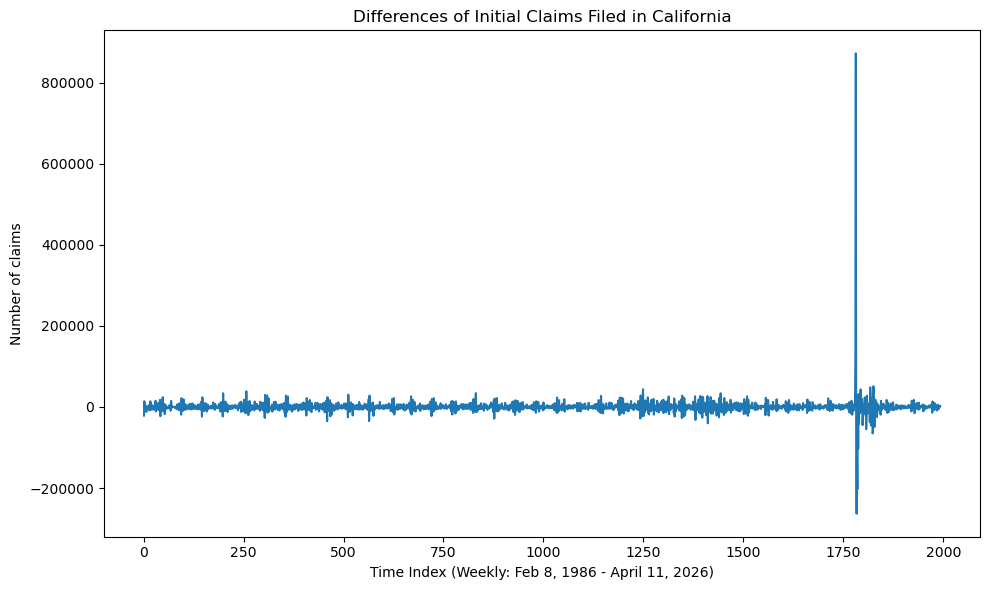

In [33]:
## Plotting it!
plt.figure(figsize=(10,6))
plt.plot(ytrain_CA_diff.dropna())
plt.xlabel("Time Index (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.title("Differences of Initial Claims Filed in California")
plt.tight_layout()
plt.show();

### **Design Matrix Construction**

**Code cell purpose:** Cell below has function to briefly define exogenous SARIMAX features, specifically Fourier seasonality, trend, and post-COVID indicator.  This matters because the SARIMAX model needs interpretable exogenous features to capture seasonality, trend, and COVID-related structural change.

In [34]:
def make_features(n, covid_start=1780):
    t = np.arange(n)
    X = pd.DataFrame({"trend": t}, index=np.arange(n))
    for k in range(1, 4):
        X[f"sin_{k}"] = np.sin(2 * np.pi * k * t / 52)
        X[f"cos_{k}"] = np.cos(2 * np.pi * k * t / 52)
    X["covid_after"] = (t >= covid_start).astype(int)
    return X


### **SARIMAX Model Testing**

**Code cell purpose:** Building the actual design matrices for SARIMAX, fitting baseline exogenous model utilizing best ARIMA order. This matters because it creates the actual exogenous matrices used to estimate and forecast the SARIMAX baseline.

In [35]:
## Exog features through observed data only (for holdout RMSE/grid search)
X_CA = make_features(len(y_CA), covid_start=1780)

Xtrain_CA = X_CA.iloc[:train_end]
Xtest_CA = X_CA.iloc[train_end:len(y_CA)]
Xtest_CA = Xtest_CA[Xtrain_CA.columns]

## Exog through observed data and future period (for extended future forecasts)
X_CA_extended = make_features(len(y_CA) + test_horizon, covid_start=1780)

Xtrain_CA_extended = X_CA_extended.iloc[:train_end]
Xtest_CA_extended = X_CA_extended.iloc[train_end : len(y_CA) + test_horizon]
Xtest_CA_extended = Xtest_CA_extended[Xtrain_CA_extended.columns]


## Baseline SARIMAX uses the best holdout-RMSE ARIMA order, then adds the exogenous terms
sarimax_model = SARIMAX(
    ytrain_CA,
    exog=Xtrain_CA_extended,
    order=(int(best_rmse["p"]), int(best_rmse["d"]), int(best_rmse["q"])),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarimax_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:               SARIMAX(8, 1, 0)   Log Likelihood              -22661.539
Date:                Sun, 03 May 2026   AIC                          45357.079
Time:                        02:52:16   BIC                          45452.157
Sample:                             0   HQIC                         45392.004
                               - 1993                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
trend         -79.4505    615.006     -0.129      0.897   -1284.840    1125.939
sin_1        2431.3356   7173.555      0.339      0.735   -1.16e+04    1.65e+04
cos_1        3340.7817   7575.560      0.441    

**Code cell purpose:** Here, having the entire California train-test split plotted such that forecasting setup is clear visually.  This matters because the plot verifies that the SARIMAX forecast is being evaluated over the intended holdout window.

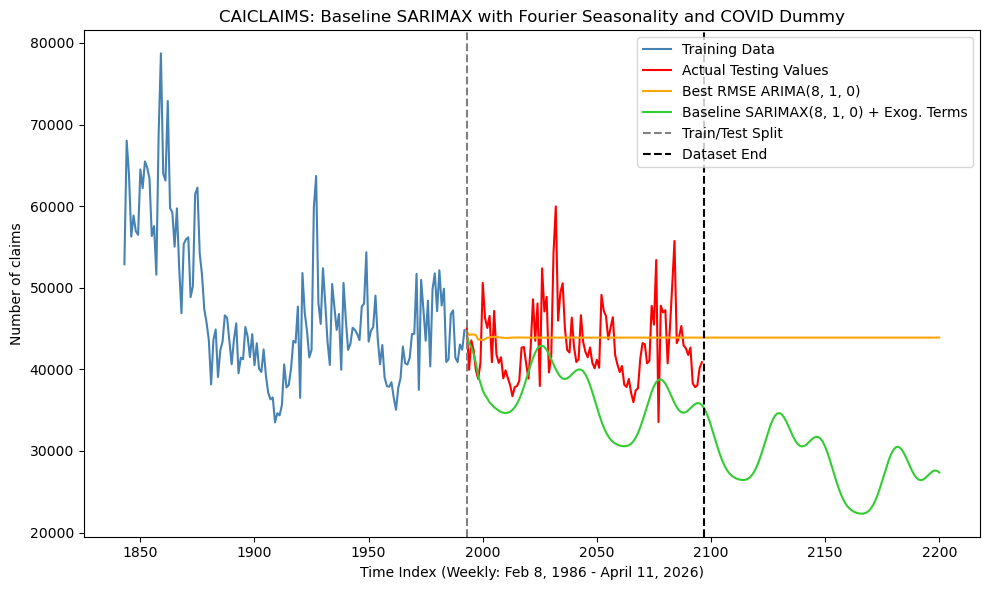

Root Mean Squared Error of Best RMSE ARIMA(8, 1, 0) Model: 4599.134
Root Mean Squared Error of Baseline SARIMAX(8, 1, 0) Model: 7840.432


In [36]:
## Forecast the test period plus an additional 2-year future window.
sarimax_fcast = sarimax_model.get_forecast(steps=len(ytest_CA) + test_horizon, exog=Xtest_CA_extended)
sarimax_yhat = sarimax_fcast.predicted_mean
sarimax_yhat.index = tpred
sarimax_rmse = np.sqrt(mean_squared_error(ytest_CA, sarimax_yhat.iloc[:len(ytest_CA)]))


## Plot predictions against ARIMA baselines and actual values.
plt.figure(figsize=(10, 6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA.iloc[(train_end - 150):], label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Actual Testing Values", color="red")

plt.plot(tpred, best_rmse_yhat, color="orange",
         label=f"Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])})")
plt.plot(tpred, sarimax_yhat, color="limegreen",
         label=f"Baseline SARIMAX({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) + Exog. Terms")

plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split" )
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End")

plt.title("CAICLAIMS: Baseline SARIMAX with Fourier Seasonality and COVID Dummy")
plt.xlabel("Time Index (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();


print(f"Root Mean Squared Error of Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {best_rmse_rmse:.3f}")
print(f"Root Mean Squared Error of Baseline SARIMAX({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {sarimax_rmse:.3f}")

### **Parameter Selection (Grid Search)**

**Code cell purpose:** Cell below defines the SARIMAX grid-search helper for post-COVID speciifcation.  This matters because a consistent helper lets the SARIMAX grid compare many orders using the same exogenous controls and RMSE metric.

In [37]:
## Parameters
pmax, dmax, qmax = 8, 1, 6

## Brief function
def fit_sarimax_exog(params):
    p, d, q = map(int, params)
    try:
        model = SARIMAX(ytrain_CA, exog=Xtrain_CA, order=(p, d, q), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        y_hat = model.get_forecast(steps=len(ytest_CA), exog=Xtest_CA).predicted_mean
        y_hat.index = ytest_CA.index
        rmse = np.sqrt(mean_squared_error(ytest_CA, y_hat))
        return {"p": p, "d": d, "q": q, "AIC": model.aic, "BIC": model.bic, "RMSE": rmse}
    except Exception:
        return None


**Code cell purpose:** Running/loading the SARIMAX grid search for post-COVID specification.  This matters because caching makes the SARIMAX model search reproducible without forcing long reruns after results are saved.

In [38]:
## Setting up the path
cache_path_sarimax = "CAICLAIMS_Model_Cache/sarimax_grid_results_CAICLAIMS.csv"

## Grid for parameters
param_grid = list(itertools.product(
    range(pmax + 1),
    range(dmax + 1),
    range(qmax + 1)
))

## Necessary columns
required_sarimax_cols = {"p", "d", "q", "AIC", "BIC", "RMSE"}

## Setting up the process
if os.path.exists(cache_path_sarimax):
    print(f"Loading cached SARIMAX grid search results from {cache_path_sarimax}")
    results_sarimax_df = pd.read_csv(cache_path_sarimax)

    ## Re-run if the cache is not in the expected format
    if not required_sarimax_cols.issubset(results_sarimax_df.columns):
        print("Cached SARIMAX results are missing the required columns, so the grid search needs to be run again!")
        results_sarimax_df = pd.DataFrame()

else:
    results_sarimax_df = pd.DataFrame()

if results_sarimax_df.empty:
    print("Running SARIMAX grid search!")

    results_sarimax = Parallel(n_jobs=-1, verbose=10)(
        delayed(fit_sarimax_exog)(params) for params in param_grid
    )

    results_sarimax = [r for r in results_sarimax if r is not None]
    results_sarimax_df = pd.DataFrame(results_sarimax)

    if results_sarimax_df.empty:
        raise ValueError(
            "SARIMAX grid search failed, meaning no models were successfully fit!"
            "Please check that len(Xtest_CA) equals len(ytest_CA)."
        )

    results_sarimax_df.to_csv(cache_path_sarimax, index=False)
    print(f"Saved SARIMAX grid search results to {cache_path_sarimax}")

## Showing the best few models by holdout RMSE for transparency
display(results_sarimax_df.sort_values("RMSE").head(10).round(3))

Loading cached SARIMAX grid search results from CAICLAIMS_Model_Cache/sarimax_grid_results_CAICLAIMS.csv


,p,d,q,AIC,BIC,RMSE
7,0,1,0,"58,858.05","58,908.42","7,120.88"
120,8,1,1,"45,310.04","45,410.71","7,139.81"
109,7,1,4,"45,332.23","45,444.10","7,153.02"
97,6,1,6,"45,336.91","45,454.37","7,161.53"
83,5,1,6,"45,334.92","45,446.79","7,163.80"
69,4,1,6,"45,332.86","45,439.14","7,166.95"
95,6,1,4,"45,355.52","45,461.80","7,167.27"
121,8,1,2,"45,310.80","45,417.06","7,171.70"
122,8,1,3,"45,312.05","45,423.91","7,172.84"
82,5,1,5,"45,354.77","45,461.05","7,174.10"


### **Best Models by Evaluation Metrics**

**Code cell purpose:** Extracting the best SARIMAX specifications according to the metrics of AIC, BIC, and holdout RMSE.
This matters because it separates the best model by information criteria from the best model by forecast accuracy.

In [39]:
## BEst specifications
best_aic_sarimax = results_sarimax_df.loc[results_sarimax_df["AIC"].idxmin()]
best_bic_sarimax = results_sarimax_df.loc[results_sarimax_df["BIC"].idxmin()]
best_rmse_sarimax = results_sarimax_df.loc[results_sarimax_df["RMSE"].idxmin()]

## Printing out respective messages for metrics
print(
    f"Best model by AIC: SARIMAX({int(best_aic_sarimax['p'])}, "
    f"{int(best_aic_sarimax['d'])}, {int(best_aic_sarimax['q'])}), "
    f"AIC: {best_aic_sarimax['AIC']:.3f}, "
    f"BIC: {best_aic_sarimax['BIC']:.3f}, "
    f"RMSE: {best_aic_sarimax['RMSE']:.3f}"
)

print(
    f"Best model by BIC: SARIMAX({int(best_bic_sarimax['p'])}, "
    f"{int(best_bic_sarimax['d'])}, {int(best_bic_sarimax['q'])}), "
    f"AIC: {best_bic_sarimax['AIC']:.3f}, "
    f"BIC: {best_bic_sarimax['BIC']:.3f}, "
    f"RMSE: {best_bic_sarimax['RMSE']:.3f}"
)

print(
    f"Best model by RMSE: SARIMAX({int(best_rmse_sarimax['p'])}, "
    f"{int(best_rmse_sarimax['d'])}, {int(best_rmse_sarimax['q'])}), "
    f"AIC: {best_rmse_sarimax['AIC']:.3f}, "
    f"BIC: {best_rmse_sarimax['BIC']:.3f}, "
    f"RMSE: {best_rmse_sarimax['RMSE']:.3f}"
)

Best model by AIC: SARIMAX(8, 1, 1), AIC: 45310.035, BIC: 45410.707, RMSE: 7139.811
Best model by BIC: SARIMAX(8, 1, 1), AIC: 45310.035, BIC: 45410.707, RMSE: 7139.811
Best model by RMSE: SARIMAX(0, 1, 0), AIC: 58858.051, BIC: 58908.419, RMSE: 7120.883


**Code cell purpose:** Cell fits best holdout-RMSE SARIMAX model, also prints out summary.
This matters because the summary gives coefficient and diagnostic detail for the strongest holdout-RMSE SARIMAX specification.

In [40]:
## Best values
best_p = int(best_rmse_sarimax["p"])
best_d = int(best_rmse_sarimax["d"])
best_q = int(best_rmse_sarimax["q"])

## Best model
best_rmse_sarimax_model = SARIMAX(
    ytrain_CA,
    exog=Xtrain_CA_extended,
    order=(best_p, best_d, best_q),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(best_rmse_sarimax_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:               SARIMAX(0, 1, 0)   Log Likelihood              -29420.026
Date:                Sun, 03 May 2026   AIC                          58858.051
Time:                        02:52:16   BIC                          58908.419
Sample:                             0   HQIC                         58876.550
                               - 1993                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
trend         -79.4505   2.55e+06  -3.11e-05      1.000   -5.01e+06    5.01e+06
sin_1        2431.3356    3.2e+07    7.6e-05      1.000   -6.27e+07    6.27e+07
cos_1        3340.7817   2.83e+07      0.000    

### **Plotting the SARIMAX Predictions**

**Code cell purpose:** Plotting entire California train-test split to have clear visualization of the forecasting setup.
This matters because the plot directly compares ARIMA and SARIMAX forecasts over the same testing period.

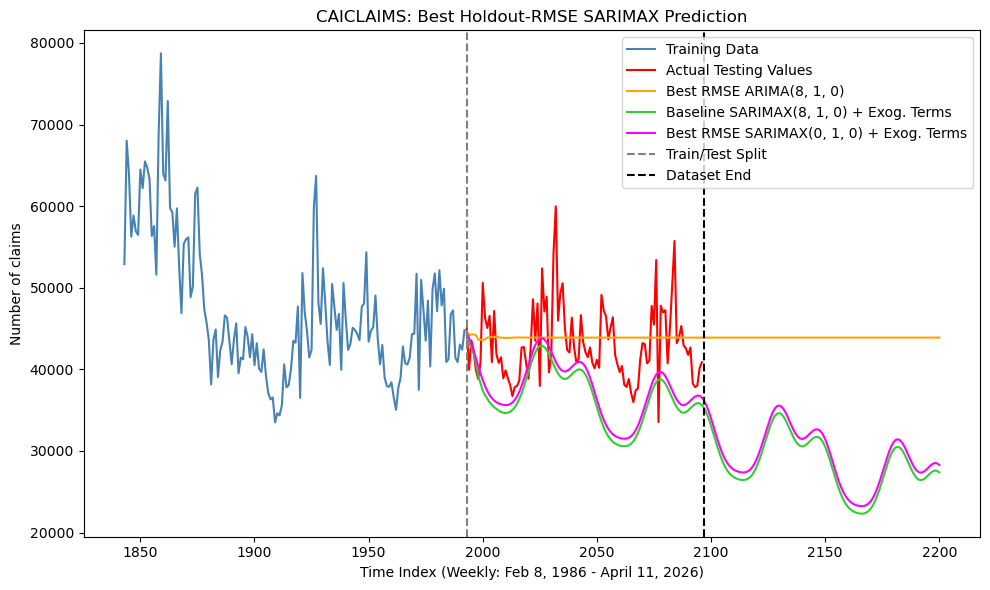

Root Mean Squared Error of Best RMSE ARIMA(8, 1, 0) Model: 4599.134
Root Mean Squared Error of Baseline SARIMAX(8, 1, 0) Model: 7840.432
Root Mean Squared Error of Best RMSE SARIMAX(0, 1, 0) Model: 7120.883


In [41]:
## Our best forcasting model
best_rmse_sarimax_fcast = best_rmse_sarimax_model.get_forecast(
    steps=len(ytest_CA) + test_horizon,
    exog=Xtest_CA_extended
)

## Best predictors
best_rmse_sarimax_yhat = best_rmse_sarimax_fcast.predicted_mean
best_rmse_sarimax_yhat.index = tpred
best_sarimax_rmse = np.sqrt(mean_squared_error(ytest_CA, best_rmse_sarimax_yhat.iloc[:len(ytest_CA)]))

## Plotting
plt.figure(figsize=(10, 6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA.iloc[(train_end - 150):], label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Actual Testing Values", color="red")

plt.plot(tpred, best_rmse_yhat, color="orange",
         label=f"Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])})")
plt.plot(tpred, sarimax_yhat, color="limegreen",
         label=f"Baseline SARIMAX({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) + Exog. Terms")
plt.plot(tpred, best_rmse_sarimax_yhat, color="magenta",
         label=f"Best RMSE SARIMAX({best_p}, {best_d}, {best_q}) + Exog. Terms")

plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End")

plt.title("CAICLAIMS: Best Holdout-RMSE SARIMAX Prediction")
plt.xlabel("Time Index (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();


print(f"Root Mean Squared Error of Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {best_rmse_rmse:.3f}")
print(f"Root Mean Squared Error of Baseline SARIMAX({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {sarimax_rmse:.3f}")
print(f"Root Mean Squared Error of Best RMSE SARIMAX({best_p}, {best_d}, {best_q}) Model: {best_sarimax_rmse:.3f}")

## **3. SARIMAX with Fourier Frequencies, During COVID Dummy**

**Code cell purpose:** Plotting entire California train-test split so forecasting setup is visually clear.
This matters because the visualization anchors the second SARIMAX specification to the same train/test forecasting setup.

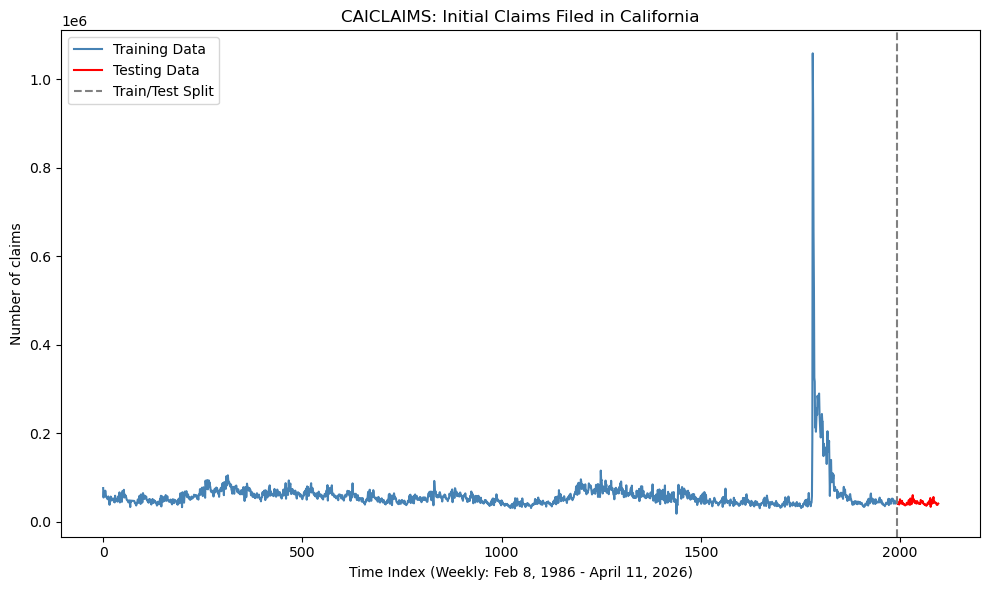

In [42]:
## Plotting
plt.figure(figsize=(10, 6))
plt.plot(ttrain, ytrain_CA, label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Testing Data", color="red")
plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.title("CAICLAIMS: Initial Claims Filed in California")
plt.xlabel("Time Index (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();

**Code cell purpose:** Replotting initial differences prior to SARIMAX section so that we keep the model diagnostics similar to the model code.  This matters because it keeps the stationarity and differencing logic visible before the alternative COVID specification is fit.

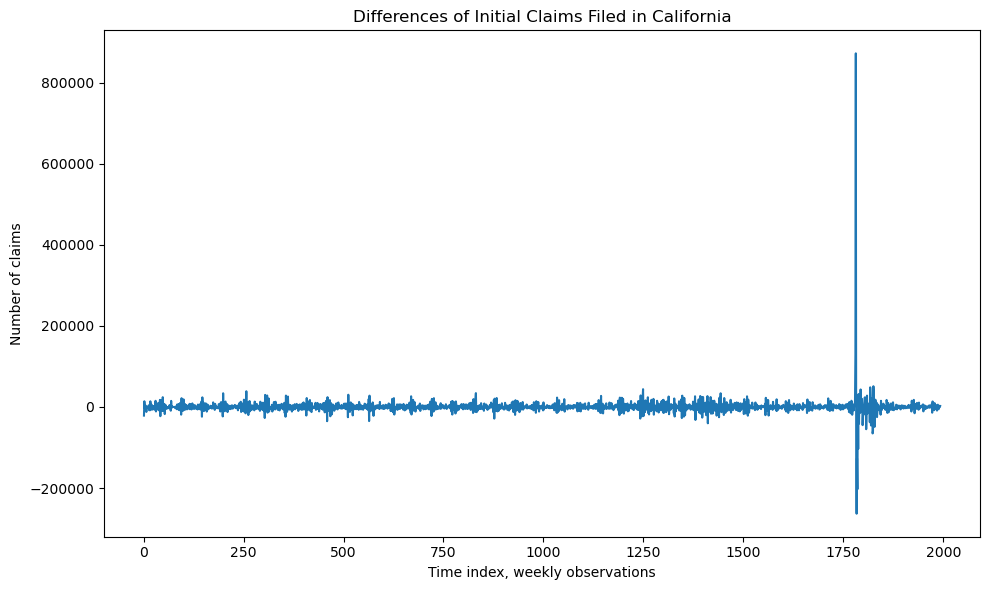

In [43]:
## Plotting
plt.figure(figsize=(10,6))
plt.plot(ytrain_CA_diff.dropna())
plt.xlabel("Time index, weekly observations")
plt.ylabel("Number of claims")
plt.title("Differences of Initial Claims Filed in California")
plt.tight_layout()
plt.show();

### **Design Matrix Construction**

**Code cell purpose:** Defines alternative SARIMAX feature set with a during-COVID indicator instead of a post-COVID indicator. This matters because the during-COVID indicator treats the pandemic shock as a temporary disruption rather than a permanent post-COVID shift.

In [44]:
## Brief function
def make_features_new(n, covid_start=1775, covid_end=1860, n_harmonics=3):
    t = np.arange(n)
    X = pd.DataFrame({"trend": t}, index=np.arange(n))
    for k in range(1, n_harmonics + 1):
        X[f"sin_{k}"] = np.sin(2 * np.pi * k * t / 52)
        X[f"cos_{k}"] = np.cos(2 * np.pi * k * t / 52)
    X["during_covid"] = ((t >= covid_start) & (t <= covid_end)).astype(int)
    return X


**Code cell purpose:** Builds observed and extended feature matrices for the during-COVID SARIMAX specification.
This matters because SARIMAX requires the same exogenous columns to exist for both the observed sample and forecast horizon.

In [45]:
## Exog features through observed data only (for holdout RMSE/grid search)
X_CA_new = make_features_new(n=len(y_CA), covid_start=1775, covid_end=1860, n_harmonics=3)

## Training/Test set
Xtrain_CA_new = X_CA_new.iloc[:train_end]
Xtest_CA_new = X_CA_new.iloc[train_end:len(y_CA)]
Xtest_CA_new = Xtest_CA_new[Xtrain_CA_new.columns]

## Exog through observed data and future period (for extended future forecasts)
X_CA_new_extended = make_features_new(n=len(y_CA) + test_horizon, covid_start=1775, covid_end=1860, n_harmonics=3)

## Extended model
Xtrain_CA_new_extended = X_CA_new_extended.iloc[:train_end]
Xtest_CA_new_extended = X_CA_new_extended.iloc[train_end : len(y_CA) + test_horizon]
Xtest_CA_new_extended = Xtest_CA_new_extended[Xtrain_CA_new_extended.columns]

### **Parameter Selection (Grid Search)**

**Code cell purpose:** Cell below sets up a couple of brief functions to define short rolling-origin cross-validation helpers, specifically for the SARIMAX (during-COVID) specification. This matters because rolling-origin validation evaluates whether a SARIMAX order forecasts well across multiple historical splits.

In [46]:
## Row function
def cv_row(order, train_end_cv, horizon, rmse, aic, bic, status):
    p, d, q = map(int, order)
    return {"train_end": train_end_cv, "test_start": train_end_cv, "test_end": train_end_cv + horizon - 1, "p": p, "d": d, "q": q, "RMSE": rmse, "AIC": aic, "BIC": bic, "status": status}

## Necessary slicing
def cv_slices(y, X, train_end_cv, horizon):
    y_train = y.iloc[:train_end_cv]
    y_test = y.iloc[train_end_cv:train_end_cv + horizon]
    X_train = X.iloc[:train_end_cv]
    X_test = X.iloc[train_end_cv:train_end_cv + horizon][X_train.columns]
    return y_train, y_test, X_train, X_test

## Fitting function
def cv_fit_one(y, X, order, train_end_cv, horizon):
    y_train, y_test, X_train, X_test = cv_slices(y, X, train_end_cv, horizon)
    try:
        model = SARIMAX(y_train, exog=X_train, order=tuple(map(int, order)), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        y_hat = model.get_forecast(steps=horizon, exog=X_test).predicted_mean
        rmse = np.sqrt(mean_squared_error(y_test, y_hat))
        return cv_row(order, train_end_cv, horizon, rmse, model.aic, model.bic, "success")
    except Exception:
        return cv_row(order, train_end_cv, horizon, np.nan, np.nan, np.nan, "failed")

## Producing summary
def cv_summary(order, cv_results):
    p, d, q = map(int, order)
    return {"p": p, "d": d, "q": q, "CV_RMSE": cv_results["RMSE"].mean(skipna=True), "CV_AIC": cv_results["AIC"].mean(skipna=True), "CV_BIC": cv_results["BIC"].mean(skipna=True), "n_success": cv_results["RMSE"].notna().sum(), "n_splits": len(cv_results)}

## Rolling-origin
def rolling_cv_sarimax(y, X, order, initial_train_size=1500, horizon=52, step=26):
    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True)
    split_points = range(initial_train_size, len(y) - horizon + 1, step)
    rows = [cv_fit_one(y, X, order, split, horizon) for split in split_points]
    return cv_summary(order, pd.DataFrame(rows))


**Code cell purpose:** Runs/loads the rolling-origin cross-validation for SARIMAX during-COVID grid.
This matters because it uses cached validation results when available and otherwise builds a more robust SARIMAX order comparison.

In [47]:
## Path
cache_path = "CAICLAIMS_Model_Cache/sarimax_cv_grid_results_CAICLAIMS.csv"

## Parameters
pmax, dmax, qmax = 8, 1, 6

## Parameter grid
param_grid = list(itertools.product(
    range(pmax + 1),
    range(dmax + 1),
    range(qmax + 1)
))

## Initial setups
initial_train_size = 1500
horizon = 52
step = 26

## Brief function for order evaluation
def evaluate_order_cv(order):
    return rolling_cv_sarimax(
        y=ytrain_CA, X=Xtrain_CA_new, order=order,
        initial_train_size=initial_train_size, horizon=horizon, step=step
    )

## Necessary columns
required_cv_cols = {"p", "d", "q", "CV_RMSE", "CV_AIC", "CV_BIC", "n_success", "n_splits"}

## Running everything
if os.path.exists(cache_path):
    print(f"Loading cached grid search results from {cache_path}")
    results_sarimax_new_df = pd.read_csv(cache_path)

    ## Re-run if the cache is not in the expected format.
    if not required_cv_cols.issubset(results_sarimax_new_df.columns):
        print("Cached rolling-CV SARIMAX results are missing required columns, so the grid search needs to be run again!")
        results_sarimax_new_df = pd.DataFrame()

else:
    results_sarimax_new_df = pd.DataFrame()

if results_sarimax_new_df.empty:
    print("Running SARIMAX rolling-CV grid search!")

    results_sarimax_new = Parallel(n_jobs=-1, verbose=10)(
        delayed(evaluate_order_cv)(order) for order in param_grid
    )

    results_sarimax_new_df = pd.DataFrame(results_sarimax_new)

    ## Saving cache so the notebook can be run again quickly
    results_sarimax_new_df.to_csv(cache_path, index=False)
    print(f"Saved grid search results to {cache_path}")


Loading cached grid search results from CAICLAIMS_Model_Cache/sarimax_cv_grid_results_CAICLAIMS.csv


### **Best Models by Evaluation Metrics**

**Code cell purpose:** Cell below completes cleaning and ranking of the rolling-CV SARIMAX grid results by cross-validation RMSE.
This matters because sorting the cross-validation results identifies the SARIMAX order with the strongest repeated forecasting performance.

In [48]:
## Clean and sort results
results_sarimax_new_df = results_sarimax_new_df.dropna(subset=["CV_RMSE"])
results_sarimax_new_df = results_sarimax_new_df.sort_values("CV_RMSE").reset_index(drop=True)

print("Top SARIMAX models by rolling-origin CV RMSE:")
display(results_sarimax_new_df.head(10))

Top SARIMAX models by rolling-origin CV RMSE:


,p,d,q,CV_RMSE,CV_AIC,CV_BIC,n_success,n_splits
0,0,1,1,"47,712.63","36,588.57","36,642.95",17,17
1,1,1,0,"47,925.95","36,835.75","36,890.14",17,17
2,0,1,0,"48,233.20","48,112.16","48,161.11",17,17
3,0,1,5,"48,303.72","36,424.06","36,500.17",17,17
4,2,1,3,"48,985.65","36,554.06","36,630.18",17,17
5,2,1,6,"49,343.47","36,380.53","36,472.94",17,17
6,2,1,5,"49,509.07","36,401.95","36,488.93",17,17
7,1,1,3,"49,546.19","36,467.11","36,537.79",17,17
8,1,1,2,"49,645.13","36,497.52","36,562.78",17,17
9,1,1,6,"49,664.51","36,398.65","36,485.62",17,17


**Code cell purpose:** Cell stores the best rolling-CV SARIMAX order, also prints its CV diagnostics.
This matters because the chosen rolling-CV order is carried into the final holdout forecast and comparison table.

In [49]:
## Generating new object
best_rmse_sarimax_new = results_sarimax_new_df.iloc[0]

## Best of different parameters
best_p_new = int(best_rmse_sarimax_new['p'])
best_d_new = int(best_rmse_sarimax_new['d'])
best_q_new = int(best_rmse_sarimax_new['q'])

## Printing
print(f"Best SARIMAX by rolling CV: SARIMAX({best_p_new}, {best_d_new}, {best_q_new})")
print(f"CV RMSE: {best_rmse_sarimax_new['CV_RMSE']:.3f}")
print(f"CV AIC: {best_rmse_sarimax_new['CV_AIC']:.3f}")
print(f"CV BIC: {best_rmse_sarimax_new['CV_BIC']:.3f}")
print(f"Successful CV splits: {int(best_rmse_sarimax_new['n_success'])} / {int(best_rmse_sarimax_new['n_splits'])}")

Best SARIMAX by rolling CV: SARIMAX(0, 1, 1)
CV RMSE: 47712.634
CV AIC: 36588.570
CV BIC: 36642.955
Successful CV splits: 17 / 17


### **Final Holdout Evaluation**

**Code cell purpose:** Forecasting from the baseline SARIMAX model and makes direct comparison with the ARIMA baseline.
This matters because it converts the selected SARIMAX specification into a final out-of-sample forecast on the same test window.

In [50]:
## Best SARIMAX model
best_rmse_sarimax_model_new = SARIMAX(
    ytrain_CA,
    exog=Xtrain_CA_new_extended,
    order=(best_p_new, best_d_new, best_q_new),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

## Summary
print(best_rmse_sarimax_model_new.summary())

## Forecasting!
best_rmse_sarimax_fcast_new = best_rmse_sarimax_model_new.get_forecast(
    steps=len(ytest_CA) + test_horizon,
    exog=Xtest_CA_new_extended
)

best_rmse_sarimax_yhat_new = best_rmse_sarimax_fcast_new.predicted_mean
best_rmse_sarimax_yhat_new.index = tpred
best_sarimax_rmse_new = np.sqrt(mean_squared_error(ytest_CA, best_rmse_sarimax_yhat_new.iloc[:len(ytest_CA)]))

print(f"\nFinal 2-year holdout RMSE for Best Rolling-CV SARIMAX({best_p_new}, {best_d_new}, {best_q_new}) Model: {best_sarimax_rmse_new:.3f}")

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:               SARIMAX(0, 1, 1)   Log Likelihood              -22855.555
Date:                Sun, 03 May 2026   AIC                          45731.110
Time:                        02:52:18   BIC                          45787.069
Sample:                             0   HQIC                         45751.662
                               - 1993                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
trend          -16.0757   1329.037     -0.012      0.990   -2620.940    2588.788
sin_1         2611.3769   1.67e+04      0.157      0.875      -3e+04    3.53e+04
cos_1         2341.5993   1.47e+04      0.15

### **Plotted SARIMAX Predictions**

**Code cell purpose:** This cell plots the entire California train-test split so the forecasting setup is visually clear.
This matters because the final plot shows how the main ARIMA and SARIMAX forecasts differ in timing and magnitude over the holdout period.

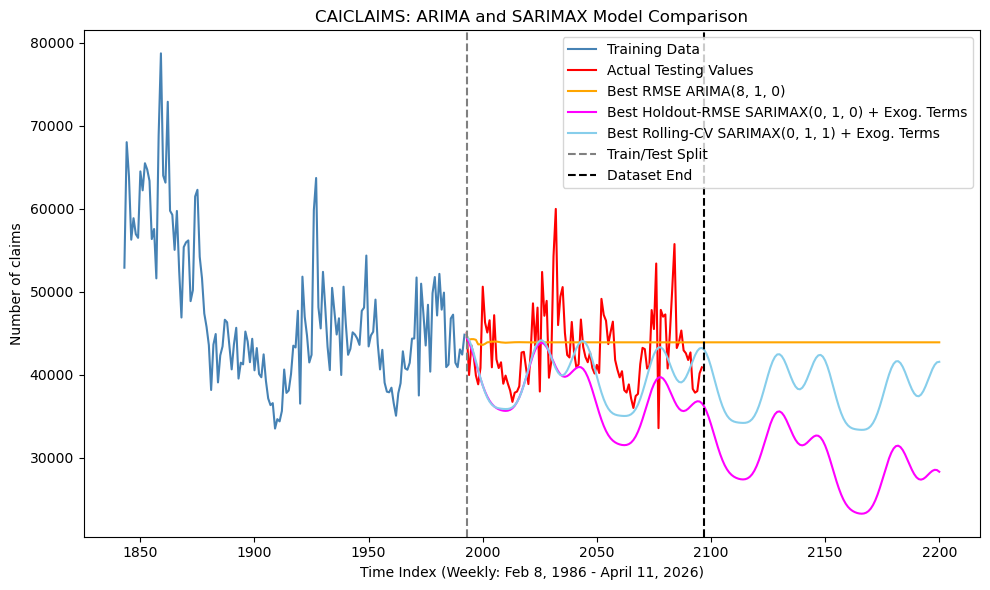

Root Mean Squared Error of Best RMSE ARIMA(8, 1, 0) Model: 4599.134
Root Mean Squared Error of Best Holdout-RMSE SARIMAX(0, 1, 0) Model: 7120.883
Root Mean Squared Error of Best Rolling-CV SARIMAX(0, 1, 1) Model: 5764.098


In [51]:
## Setting up figure
plt.figure(figsize=(10, 6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA.iloc[(train_end - 150):], label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Actual Testing Values", color="red")

## Plotting
plt.plot(tpred, best_rmse_yhat, color="orange",
         label=f"Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])})")
plt.plot(tpred, best_rmse_sarimax_yhat, color="magenta",
         label=f"Best Holdout-RMSE SARIMAX({best_p}, {best_d}, {best_q}) + Exog. Terms")
plt.plot(tpred, best_rmse_sarimax_yhat_new, color="skyblue",
         label=f"Best Rolling-CV SARIMAX({best_p_new}, {best_d_new}, {best_q_new}) + Exog. Terms")

plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End")

plt.title("CAICLAIMS: ARIMA and SARIMAX Model Comparison")
plt.xlabel("Time Index (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();

## Printing
print(f"Root Mean Squared Error of Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {best_rmse_rmse:.3f}")
print(f"Root Mean Squared Error of Best Holdout-RMSE SARIMAX({best_p}, {best_d}, {best_q}) Model: {best_sarimax_rmse:.3f}")
print(f"Root Mean Squared Error of Best Rolling-CV SARIMAX({best_p_new}, {best_d_new}, {best_q_new}) Model: {best_sarimax_rmse_new:.3f}")

## **4. SARIMAX with Fourier Frequencies, During COVID Dummy, Google Trends Data**

### **Pull and Process Google Trends Data**

In [52]:
pytrends = TrendReq(hl="en-US", tz=360)

keywords = [
    "unemployment",
    "unemployment benefits",
    "file for unemployment",
    "unemployment office",
    "apply for unemployment",
]

pytrends.build_payload(
    kw_list=keywords,
    timeframe="2004-01-01 2026-04-01",
    geo="US-CA"
)

gt_CA_pull = pytrends.interest_over_time()
gt_CA_pull = gt_CA_pull.drop(columns=["isPartial"], errors="ignore")
gt_CA_pull.index = pd.to_datetime(gt_CA_pull.index)

## Resample to Saturday weeks to match FRED claims dates
gt_CA_pull = gt_CA_pull.resample("W-SAT").mean()
gt_CA_pull.to_csv(data_dir / "google_trends_CA.csv")

display(gt_CA_pull.head())
display(gt_CA_pull.tail())

,unemployment,unemployment benefits,file for unemployment,unemployment office,apply for unemployment
date,,,,,
2004-01-03,8.00,1.00,0.00,1.00,0.00
2004-01-10,NaN,NaN,NaN,NaN,NaN
2004-01-17,NaN,NaN,NaN,NaN,NaN
2004-01-24,NaN,NaN,NaN,NaN,NaN
2004-01-31,NaN,NaN,NaN,NaN,NaN


,unemployment,unemployment benefits,file for unemployment,unemployment office,apply for unemployment
date,,,,,
2026-03-07,8.00,1.00,0.00,0.00,0.00
2026-03-14,NaN,NaN,NaN,NaN,NaN
2026-03-21,NaN,NaN,NaN,NaN,NaN
2026-03-28,NaN,NaN,NaN,NaN,NaN
2026-04-04,7.00,1.00,0.00,0.00,0.00


In [53]:
## Loading, cleaning, and aligning Google Trends to CAICLAIMS dates
def read_google_trends_state(state_abbrev):
    path = data_dir / f"google_trends_{state_abbrev}.csv"
    gt = pd.read_csv(path)
    gt = gt.rename(columns={gt.columns[0]: "Date"})
    gt["Date"] = pd.to_datetime(gt["Date"])
    return gt

def clean_google_trends_cols(gt):
    gt = gt.drop(columns=["isPartial"], errors="ignore").copy()
    trend_cols = [c for c in gt.columns if c != "Date"]
    gt[trend_cols] = gt[trend_cols].apply(pd.to_numeric, errors="coerce")
    return gt

def convert_google_dates_to_claims_week(gt):
    gt = gt.set_index("Date").sort_index()
    gt = gt.resample("W-SAT").mean()
    return gt.reset_index()

def align_google_trends(dates, gt):
    out = pd.DataFrame({"Date": pd.to_datetime(dates)})
    out = out.merge(gt, on="Date", how="left")
    trend_cols = [c for c in out.columns if c != "Date"]
    out[trend_cols] = out[trend_cols].interpolate(limit_direction="both")
    return out

gt_CA_raw = read_google_trends_state("CA")
gt_CA_clean = clean_google_trends_cols(gt_CA_raw)
gt_CA_weekly = convert_google_dates_to_claims_week(gt_CA_clean)
gt_CA_aligned = align_google_trends(date_CA, gt_CA_weekly)

display(gt_CA_weekly.head())
display(gt_CA_aligned.loc[gt_CA_aligned["Date"] >= "2004-01-01"].head())
display(gt_CA_aligned.tail())

,Date,unemployment,unemployment benefits,file for unemployment,unemployment office,apply for unemployment
0,2004-01-03,8.00,1.00,0.00,1.00,0.00
1,2004-01-10,NaN,NaN,NaN,NaN,NaN
2,2004-01-17,NaN,NaN,NaN,NaN,NaN
3,2004-01-24,NaN,NaN,NaN,NaN,NaN
4,2004-01-31,NaN,NaN,NaN,NaN,NaN


,Date,unemployment,unemployment benefits,file for unemployment,unemployment office,apply for unemployment
934,2004-01-03,8.00,1.00,0.00,1.00,0.00
935,2004-01-10,7.80,1.00,0.00,1.00,0.00
936,2004-01-17,7.60,1.00,0.00,1.00,0.00
937,2004-01-24,7.40,1.00,0.00,1.00,0.00
938,2004-01-31,7.20,1.00,0.00,1.00,0.00


,Date,unemployment,unemployment benefits,file for unemployment,unemployment office,apply for unemployment
2092,2026-03-14,7.75,1.00,0.00,0.00,0.00
2093,2026-03-21,7.50,1.00,0.00,0.00,0.00
2094,2026-03-28,7.25,1.00,0.00,0.00,0.00
2095,2026-04-04,7.00,1.00,0.00,0.00,0.00
2096,2026-04-11,7.00,1.00,0.00,0.00,0.00


In [54]:
## Quick alignment checks
trend_cols = [c for c in gt_CA_aligned.columns if c != "Date"]

print("First Google Trends weekly date:")
print(gt_CA_weekly["Date"].min())

print("\nFirst CA claims dates in 2004:")
print(date_CA[date_CA >= pd.Timestamp("2004-01-01")].head())

print("\nMissing share after alignment, full CA claims period:")
print(gt_CA_aligned[trend_cols].isna().mean())

print("\nMissing share after 2004:")
print(gt_CA_aligned.loc[gt_CA_aligned["Date"] >= "2004-01-01", trend_cols].isna().mean())

First Google Trends weekly date:
2004-01-03 00:00:00

First CA claims dates in 2004:
934   2004-01-03
935   2004-01-10
936   2004-01-17
937   2004-01-24
938   2004-01-31
Name: Date, dtype: datetime64[ns]

Missing share after alignment, full CA claims period:
unemployment             0.00
unemployment benefits    0.00
file for unemployment    0.00
unemployment office      0.00
apply for unemployment   0.00
dtype: float64

Missing share after 2004:
unemployment             0.00
unemployment benefits    0.00
file for unemployment    0.00
unemployment office      0.00
apply for unemployment   0.00
dtype: float64


### **Design Matrix Construction**

In [55]:
## Building the Google Trends model sample
def rename_google_trends_features(gt_aligned):
    trend_cols = [c for c in gt_aligned.columns if c != "Date"]
    X_gt = gt_aligned[trend_cols].copy()
    X_gt.columns = [f"gt_{c.replace(' ', '_')}" for c in trend_cols]
    return X_gt

def make_ca_gt_base_features(dates, n_harmonics=3):
    dates = pd.to_datetime(pd.Series(dates)).reset_index(drop=True)
    t = np.arange(len(dates))
    X = pd.DataFrame({"trend": t})
    for k in range(1, n_harmonics + 1):
        X[f"sin_{k}"] = np.sin(2 * np.pi * k * t / 52)
        X[f"cos_{k}"] = np.cos(2 * np.pi * k * t / 52)
    X["during_covid"] = dates.between("2020-03-14", "2021-10-02").astype(int)
    return X

def make_ca_gt_exog(dates, gt_aligned):
    X_base = make_ca_gt_base_features(dates)
    X_gt = rename_google_trends_features(gt_aligned)
    return pd.concat([X_base, X_gt.reset_index(drop=True)], axis=1)

gt_start_date_CA = gt_CA_weekly["Date"].min()
gt_start_idx_CA = int(np.where(date_CA >= gt_start_date_CA)[0][0])

y_CA_gt = y_CA.iloc[gt_start_idx_CA:].reset_index(drop=True)
date_CA_gt = date_CA.iloc[gt_start_idx_CA:].reset_index(drop=True)
gt_CA_model = gt_CA_aligned.iloc[gt_start_idx_CA:].reset_index(drop=True)

test_horizon_gt = 104
train_end_gt = len(y_CA_gt) - test_horizon_gt

ytrain_CA_gt = y_CA_gt.iloc[:train_end_gt]
ytest_CA_gt = y_CA_gt.iloc[train_end_gt:]

date_train_CA_gt = date_CA_gt.iloc[:train_end_gt]
date_test_CA_gt = date_CA_gt.iloc[train_end_gt:]

X_CA_gt = make_ca_gt_exog(date_CA_gt, gt_CA_model)
Xtrain_CA_gt = X_CA_gt.iloc[:train_end_gt]
Xtest_CA_gt = X_CA_gt.iloc[train_end_gt:][Xtrain_CA_gt.columns]

print(f"Google Trends model period: {date_CA_gt.iloc[0].date()} to {date_CA_gt.iloc[-1].date()}")
print(f"Training period: {date_train_CA_gt.iloc[0].date()} to {date_train_CA_gt.iloc[-1].date()}")
print(f"Testing period: {date_test_CA_gt.iloc[0].date()} to {date_test_CA_gt.iloc[-1].date()}")
print(f"Number of exog columns: {X_CA_gt.shape[1]}")
display(X_CA_gt.head())

Google Trends model period: 2004-01-03 to 2026-04-11
Training period: 2004-01-03 to 2024-04-13
Testing period: 2024-04-20 to 2026-04-11
Number of exog columns: 13


,trend,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3,during_covid,gt_unemployment,gt_unemployment_benefits,gt_file_for_unemployment,gt_unemployment_office,gt_apply_for_unemployment
0,0,0.00,1.00,0.00,1.00,0.00,1.00,0,8.00,1.00,0.00,1.00,0.00
1,1,0.12,0.99,0.24,0.97,0.35,0.94,0,7.80,1.00,0.00,1.00,0.00
2,2,0.24,0.97,0.46,0.89,0.66,0.75,0,7.60,1.00,0.00,1.00,0.00
3,3,0.35,0.94,0.66,0.75,0.89,0.46,0,7.40,1.00,0.00,1.00,0.00
4,4,0.46,0.89,0.82,0.57,0.99,0.12,0,7.20,1.00,0.00,1.00,0.00


### **Parameter Selection (Grid Search)**

In [56]:
## Rolling-CV helper functions for SARIMAX + Google Trends
def gt_cv_slices(y, X, train_end_cv, horizon):
    y_train = y.iloc[:train_end_cv]
    y_test = y.iloc[train_end_cv:train_end_cv + horizon]
    X_train = X.iloc[:train_end_cv]
    X_test = X.iloc[train_end_cv:train_end_cv + horizon][X_train.columns]
    return y_train, y_test, X_train, X_test

def gt_cv_row(order, split, horizon, rmse, aic, bic, status):
    p, d, q = map(int, order)
    return {"train_end": split, "test_start": split, "test_end": split + horizon - 1,
            "p": p, "d": d, "q": q, "RMSE": rmse, "AIC": aic, "BIC": bic, "status": status}

def gt_cv_fit_one(y, X, order, split, horizon):
    y_tr, y_te, X_tr, X_te = gt_cv_slices(y, X, split, horizon)
    try:
        model = SARIMAX(y_tr, exog=X_tr, order=tuple(map(int, order)),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        pred = model.get_forecast(steps=horizon, exog=X_te).predicted_mean
        return gt_cv_row(order, split, horizon, np.sqrt(mean_squared_error(y_te, pred)), model.aic, model.bic, "success")
    except Exception:
        return gt_cv_row(order, split, horizon, np.nan, np.nan, np.nan, "failed")

def gt_cv_summary(order, rows):
    p, d, q = map(int, order)
    df = pd.DataFrame(rows)
    return {"p": p, "d": d, "q": q, "CV_RMSE": df["RMSE"].mean(skipna=True),
            "CV_AIC": df["AIC"].mean(skipna=True), "CV_BIC": df["BIC"].mean(skipna=True),
            "n_success": df["RMSE"].notna().sum(), "n_splits": len(df)}

def rolling_cv_sarimax_gt(y, X, order, initial_train_size=600, horizon=52, step=26):
    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True)
    splits = range(initial_train_size, len(y) - horizon + 1, step)
    rows = [gt_cv_fit_one(y, X, order, split, horizon) for split in splits]
    return gt_cv_summary(order, rows)

In [81]:
cache_path_gt = "CAICLAIMS_Model_Cache/sarimax_cv_gt_grid_results_CAICLAIMS.csv"

pmax, dmax, qmax = 8, 1, 6

param_grid_gt = list(itertools.product(
    range(pmax + 1),
    range(dmax + 1),
    range(qmax + 1)
))

initial_train_size_gt = 600
horizon_gt = 52
step_gt = 26

required_gt_cv_cols = {
    "p", "d", "q", "CV_RMSE", "CV_AIC", "CV_BIC", "n_success", "n_splits"
}

def evaluate_order_cv_gt(order):
    return rolling_cv_sarimax_gt(
        y=ytrain_CA_gt,
        X=Xtrain_CA_gt,
        order=order,
        initial_train_size=initial_train_size_gt,
        horizon=horizon_gt,
        step=step_gt
    )

if os.path.exists(cache_path_gt):
    print(f"Loading cached Google Trends SARIMAX CV results from {cache_path_gt}")
    results_sarimax_gt_df = pd.read_csv(cache_path_gt)
    if not required_gt_cv_cols.issubset(results_sarimax_gt_df.columns):
        results_sarimax_gt_df = pd.DataFrame()
else:
    results_sarimax_gt_df = pd.DataFrame()

if results_sarimax_gt_df.empty:
    print("Running SARIMAX + Google Trends rolling-CV grid search!")
    results_sarimax_gt = Parallel(n_jobs=-1, verbose=10)(
        delayed(evaluate_order_cv_gt)(order) for order in param_grid_gt
    )
    results_sarimax_gt_df = pd.DataFrame(results_sarimax_gt)
    results_sarimax_gt_df.to_csv(cache_path_gt, index=False)
    print(f"Saved Google Trends SARIMAX CV results to {cache_path_gt}")

Loading cached Google Trends SARIMAX CV results from CAICLAIMS_Model_Cache/sarimax_cv_gt_grid_results_CAICLAIMS.csv


### **Best Models by Evaluation Metrics**

In [58]:
## Selecting the best SARIMAX + Google Trends model by rolling-CV RMSE
results_sarimax_gt_df = results_sarimax_gt_df.dropna(subset=["CV_RMSE"])
results_sarimax_gt_df = results_sarimax_gt_df.sort_values("CV_RMSE").reset_index(drop=True)

print("Top SARIMAX + Google Trends models by rolling-origin CV RMSE:")
display(results_sarimax_gt_df.head(10).round(3))

Top SARIMAX + Google Trends models by rolling-origin CV RMSE:


,p,d,q,CV_RMSE,CV_AIC,CV_BIC,n_success,n_splits
0,5,0,2,"30,633.85","17,271.85","17,369.72",16,16
1,1,0,3,"30,707.57","17,297.20","17,381.11",16,16
2,1,0,1,"30,710.22","17,345.55","17,420.18",16,16
3,1,0,2,"30,728.18","17,324.09","17,403.36",16,16
4,5,0,1,"30,752.57","17,273.12","17,366.33",16,16
5,1,0,0,"30,757.91","17,426.96","17,496.94",16,16
6,4,0,1,"30,778.14","17,294.74","17,383.31",16,16
7,2,0,6,"30,796.02","17,230.47","17,332.94",16,16
8,2,0,0,"30,813.16","17,354.94","17,429.56",16,16
9,0,0,3,"30,821.83","17,367.46","17,446.71",16,16


In [59]:
best_rmse_sarimax_gt = results_sarimax_gt_df.iloc[0]

best_p_gt = int(best_rmse_sarimax_gt["p"])
best_d_gt = int(best_rmse_sarimax_gt["d"])
best_q_gt = int(best_rmse_sarimax_gt["q"])

print(f"Best SARIMAX + Google Trends by rolling CV: SARIMAX({best_p_gt}, {best_d_gt}, {best_q_gt})")
print(f"CV RMSE: {best_rmse_sarimax_gt['CV_RMSE']:.3f}")
print(f"CV AIC: {best_rmse_sarimax_gt['CV_AIC']:.3f}")
print(f"CV BIC: {best_rmse_sarimax_gt['CV_BIC']:.3f}")
print(f"Successful CV splits: {int(best_rmse_sarimax_gt['n_success'])} / {int(best_rmse_sarimax_gt['n_splits'])}")

Best SARIMAX + Google Trends by rolling CV: SARIMAX(5, 0, 2)
CV RMSE: 30633.854
CV AIC: 17271.851
CV BIC: 17369.717
Successful CV splits: 16 / 16


### **Final Holdout Evaluation**

In [60]:
## Final two-year holdout evaluation, no future forecast due to Google Trends data only being available through the end of the observed period.
best_rmse_sarimax_gt_model = SARIMAX(
    ytrain_CA_gt,
    exog=Xtrain_CA_gt,
    order=(best_p_gt, best_d_gt, best_q_gt),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(best_rmse_sarimax_gt_model.summary())

best_rmse_sarimax_gt_fcast = best_rmse_sarimax_gt_model.get_forecast(
    steps=len(ytest_CA_gt),
    exog=Xtest_CA_gt
)

best_rmse_sarimax_gt_yhat = best_rmse_sarimax_gt_fcast.predicted_mean
best_rmse_sarimax_gt_yhat.index = ytest_CA_gt.index
best_sarimax_rmse_gt = np.sqrt(mean_squared_error(ytest_CA_gt, best_rmse_sarimax_gt_yhat))

print(f"\nFinal 2-year holdout RMSE for Best Rolling-CV SARIMAX({best_p_gt}, {best_d_gt}, {best_q_gt}) + Google Trends Model: {best_sarimax_rmse_gt:.3f}")

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1059
Model:               SARIMAX(5, 0, 2)   Log Likelihood              -12180.957
Date:                Sun, 03 May 2026   AIC                          24403.913
Time:                        03:11:24   BIC                          24508.081
Sample:                             0   HQIC                         24443.403
                               - 1059                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
trend                        -1.5480     12.722     -0.122      0.903     -26.482      23.386
sin_1                      -547.8992   5729.491     -0.096      0.924   -1.18e+04    1

### **Plotted SARIMAX Predictions**

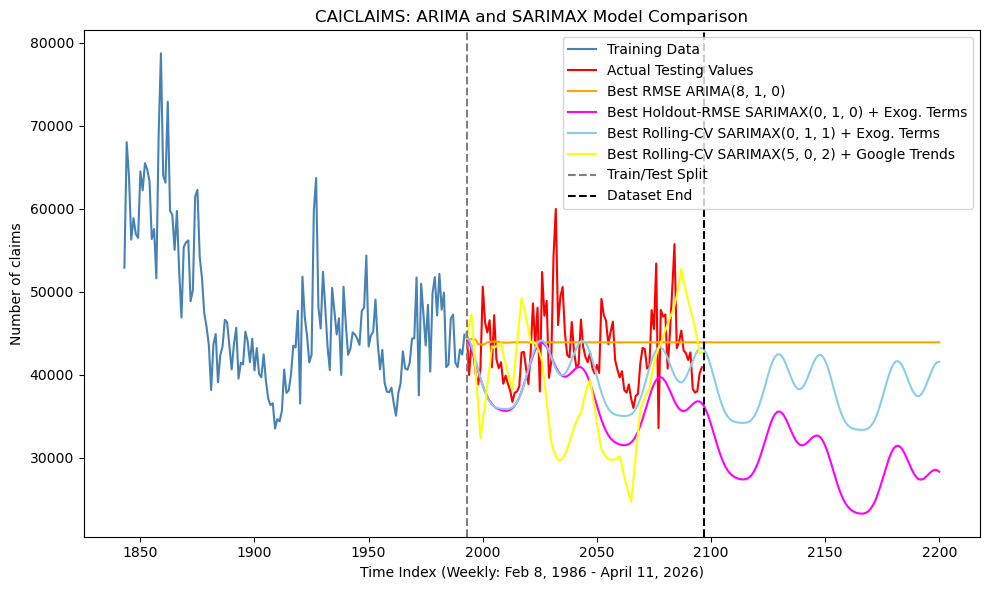

Root Mean Squared Error of Best RMSE ARIMA(8, 1, 0) Model: 4599.134
Root Mean Squared Error of Best Holdout-RMSE SARIMAX(0, 1, 0) Model: 7120.883
Root Mean Squared Error of Best Rolling-CV SARIMAX(0, 1, 1) Model: 5764.098
Root Mean Squared Error of Best Rolling-CV SARIMAX(5, 0, 2) + Google Trends Model: 9244.609


In [80]:
## Setting up figure
plt.figure(figsize=(10, 6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA.iloc[(train_end - 150):], label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Actual Testing Values", color="red")

## Plotting
plt.plot(tpred, best_rmse_yhat, color="orange",
         label=f"Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])})")
plt.plot(tpred, best_rmse_sarimax_yhat, color="magenta",
         label=f"Best Holdout-RMSE SARIMAX({best_p}, {best_d}, {best_q}) + Exog. Terms")
plt.plot(tpred, best_rmse_sarimax_yhat_new, color="skyblue",
         label=f"Best Rolling-CV SARIMAX({best_p_new}, {best_d_new}, {best_q_new}) + Exog. Terms")
plt.plot(ttest, best_rmse_sarimax_gt_yhat, color="yellow",
         label=f"Best Rolling-CV SARIMAX({best_p_gt}, {best_d_gt}, {best_q_gt}) + Google Trends")

plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End")

plt.title("CAICLAIMS: ARIMA and SARIMAX Model Comparison")
plt.xlabel("Time Index (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();

## Printing
print(f"Root Mean Squared Error of Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {best_rmse_rmse:.3f}")
print(f"Root Mean Squared Error of Best Holdout-RMSE SARIMAX({best_p}, {best_d}, {best_q}) Model: {best_sarimax_rmse:.3f}")
print(f"Root Mean Squared Error of Best Rolling-CV SARIMAX({best_p_new}, {best_d_new}, {best_q_new}) Model: {best_sarimax_rmse_new:.3f}")
print(f"Root Mean Squared Error of Best Rolling-CV SARIMAX({best_p_gt}, {best_d_gt}, {best_q_gt}) + Google Trends Model: {best_sarimax_rmse_gt:.3f}")

## **5. Model Comparison Table**

Table below provides a succint summary of the main models utilized for prediction here. What is most relevant for report/discussion is the 2-year holdout RMSE, that of which evaluates how effective any given model is at predicting observations which were not utilized in training!

**Code cell purpose:** Cell below generates concise comparison table for the main ARIMA and SARIMAX specifications.
This matters because the comparison table turns the modeling results into one concise object for interpretation and reporting.

In [62]:
model_comparison = pd.DataFrame([
    {
        "model": f"ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])})",
        "selection_rule": "Best holdout RMSE among ARIMA grid",
        "holdout_rmse": best_rmse_rmse
    },
    {
        "model": f"SARIMAX({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) + Fourier + after-COVID dummy",
        "selection_rule": "Uses best ARIMA order, then adds exog terms",
        "holdout_rmse": sarimax_rmse
    },
    {
        "model": f"SARIMAX({best_p}, {best_d}, {best_q}) + Fourier + after-COVID dummy",
        "selection_rule": "Best holdout RMSE among SARIMAX grid",
        "holdout_rmse": best_sarimax_rmse
    },
    {
        "model": f"SARIMAX({best_p_new}, {best_d_new}, {best_q_new}) + Fourier + during-COVID dummy",
        "selection_rule": "Best rolling-CV RMSE among SARIMAX grid",
        "holdout_rmse": best_sarimax_rmse_new
    },
    {
        "model": f"SARIMAX({best_p_gt}, {best_d_gt}, {best_q_gt}) + Fourier + during-COVID dummy + Google Trends",
        "selection_rule": "Best rolling-CV RMSE among SARIMAX + Google Trends grid; 2004+ sample only",
        "holdout_rmse": best_sarimax_rmse_gt
    }
])

display(model_comparison.sort_values("holdout_rmse").round(3))

,model,selection_rule,holdout_rmse
0,"ARIMA(8, 1, 0)",Best holdout RMSE among ARIMA grid,"4,599.13"
3,"SARIMAX(0, 1, 1) + Fourier + during-COVID dummy",Best rolling-CV RMSE among SARIMAX grid,"5,764.10"
2,"SARIMAX(0, 1, 0) + Fourier + after-COVID dummy",Best holdout RMSE among SARIMAX grid,"7,120.88"
1,"SARIMAX(8, 1, 0) + Fourier + after-COVID dummy","Uses best ARIMA order, then adds exog terms","7,840.43"
4,"SARIMAX(5, 0, 2) + Fourier + during-COVID dumm...",Best rolling-CV RMSE among SARIMAX + Google Tr...,"9,244.61"


# **Running Forecasting on All the States, Adding A Machine Learning Comparison**

The California-only section above where we utilized ARIMA/SARIMAX it useful as it showcases our logic and flow of work that helped guide us to build a concise pipeline. This section now builds upon that to apply the holistic forecasting workflow to all four states of analysis, California, New York, Indiana, and Hawaii! 

Additionally, the purpose of the section here is to compare an econometric time-series baseline to ML modeling processes, where both utilize the same exact two-year test data/holdout split. For each state, we perform work to fit ARIMA, SARIMAX with interpretable exogenous controls, and a LightGBM recursive forecasting model. The main shared metric is RMSE, but MAE is also included as an additional readability check. We also account for explicit handling of the COVID period. Here, the pure ARIMA model is kept as the simple benchmark, having no exogenous controls. The SARIMAX baseline includes COVID-period indicators as exogenous regressors. The LightGBM model receives the same COVID indicators as supervised-learning features, with additional lagged claims, rolling averages, and calendar seasonality.

## **1. Setup for Analyzing All States**

In the cell, we have defined our shared forecasting choice to be used across each state/model, ensuring that the two-year set at the end of the period is kept as a test. Allows us to ensure that the ARIMA, SARIMAX, and LightGBM models are evaluated on the same holdout window. We also create one model-cache folder so that grid-search results can be saved and reused instead of recomputed every run.

**Code cell purpose:** This cell defines the all-state test horizon, COVID structural-break dates, model-cache folder, and compact ARIMA/SARIMAX candidate grid. This matters because every model below needs to use the same split, the same COVID definitions, and the same saved-cache location for a fair and reproducible comparison.

In [63]:
## Shared holdout design for all states
all_state_test_horizon = 104  ## final 2 years!

## COVID dates used consistently in our SARIMAX and LightGBM modeling 
covid_break_start = pd.Timestamp("2020-03-14")
covid_break_end = pd.Timestamp("2021-10-02")

## Cache folder keeps grid-search outputs from being recomputed every run, more easy for our testing!!!
model_cache_dir = Path("Model_Cache")
model_cache_dir.mkdir(exist_ok=True)

## Compact grid for comparison of all states
all_state_pmax, all_state_dmax, all_state_qmax = 4, 1, 3
all_state_param_grid = list(itertools.product(
    range(all_state_pmax + 1),
    range(all_state_dmax + 1),
    range(all_state_qmax + 1)
))

## Printing!
print(f"All-state holdout horizon: {all_state_test_horizon} weeks")
print(f"COVID break controls: {covid_break_start.date()} through {covid_break_end.date()}")
print(f"Candidate ARIMA/SARIMAX orders per state: {len(all_state_param_grid)}")

All-state holdout horizon: 104 weeks
COVID break controls: 2020-03-14 through 2021-10-02
Candidate ARIMA/SARIMAX orders per state: 40


## **2. Some Brief Functions for Shared Splits, Metrics, and Features**

Here, we have a couple of functions that serve as helpers, working to generate the common train/test split, compute shared metrics, build SARIMAX exogenous variables, and handle simple cache validation. Keeping these utilities stored in functions makes the later all-state loops easier to read and lets us focus on actual logic of the models!

**Code cell purpose:** This cell defines some helper functions for splitting each state, computing RMSE/MAE, creating SARIMAX exogenous variables, loading valid caches, and formatting forecast outputs. This matters because the all-state comparison should repeat the same modeling logic across states without copy-pasting inconsistent code. Also, it's just smoother this way!

In [64]:
## Returns each state's series, date vector, and shared final-104-week split point
def get_state_split(code, horizon=104):
    df = claims_dfs[code].sort_values("Date").reset_index(drop=True)
    y = df["Claims"].reset_index(drop=True)
    dates = df["Date"].reset_index(drop=True)
    return df, y, dates, len(y) - horizon

## Root mean squared error
def calc_rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

## Mean absolute error
def calc_mae(actual, predicted):
    return np.mean(np.abs(np.asarray(actual) - np.asarray(predicted)))

## Creates trend, annual Fourier terms, and COVID break indicators
def make_all_state_exog(dates):
    dates = pd.to_datetime(pd.Series(dates)).reset_index(drop=True)
    t = np.arange(len(dates))
    X = pd.DataFrame({"trend": t})
    for k in range(1, 4):
        X[f"sin_{k}"] = np.sin(2 * np.pi * k * t / 52)
        X[f"cos_{k}"] = np.cos(2 * np.pi * k * t / 52)
    X["covid_during"] = dates.between(covid_break_start, covid_break_end).astype(int)
    X["covid_after"] = (dates > covid_break_end).astype(int)
    return X

## Loads cache only if it exists and has the expected columns
def load_valid_cache(cache_path, required_cols):
    if not cache_path.exists():
        return pd.DataFrame()
    cached = pd.read_csv(cache_path)
    return cached if required_cols.issubset(cached.columns) else pd.DataFrame()

## Formats holdout predictions for later tables and plots
def forecast_frame(dates, actual, prediction):
    return pd.DataFrame({
        "Date": pd.Series(dates).reset_index(drop=True),
        "Actual": pd.Series(actual).reset_index(drop=True),
        "Prediction": pd.Series(prediction).reset_index(drop=True)
    })

## **3. ARIMA Baseline Across All Four States**

ARIMA is the simplest benchmark since it uses only past values of the claims series. It doesn't explicitly receive COVID information, so it tells us how much forecasting power comes from the time-series structure alone. The code below applies the same compact ARIMA grid to all four states and caches each state's grid results. Again, helpful for testing.

**Code cell purpose:** This cell defines a short ARIMA fitting helper function and applies the ARIMA grid search to every state using the same final two-year test split. This matters because it extends the baseline model beyond California and creates a directly comparable RMSE/MAE benchmark for the later SARIMAX and LightGBM models.

In [65]:
## Fits one ARIMA order and returns holdout metrics, brief helper function
def arima_grid_row(y_train, y_test, order):
    p, d, q = map(int, order)
    try:
        model = ARIMA(y_train, order=(p, d, q)).fit()
        pred = model.get_forecast(steps=len(y_test)).predicted_mean
        pred.index = y_test.index
        return {"p": p, "d": d, "q": q, "AIC": model.aic, "BIC": model.bic, "RMSE": calc_rmse(y_test, pred), "status": "success"}
    except Exception:
        return {"p": p, "d": d, "q": q, "AIC": np.nan, "BIC": np.nan, "RMSE": np.nan, "status": "failed"}

## Storage objects for all-state ARIMA results
arima_all_results = {}
arima_all_best = []
arima_all_forecasts = {}
arima_required_cols = {"p", "d", "q", "AIC", "BIC", "RMSE", "status"}

## Looping through all the states
for code in datasets:
    df, y, dates, train_end_state = get_state_split(code, all_state_test_horizon)
    y_train = y.iloc[:train_end_state]
    y_test = y.iloc[train_end_state:]
    test_dates = dates.iloc[train_end_state:]
    cache_path = model_cache_dir / f"all_state_arima_grid_results_{code}.csv"

    results_df = load_valid_cache(cache_path, arima_required_cols)
    if results_df.empty:
        print(f"Running ARIMA grid search for {code}")
        rows = [arima_grid_row(y_train, y_test, order) for order in all_state_param_grid]
        results_df = pd.DataFrame(rows)
        results_df.to_csv(cache_path, index=False)

    valid_results = results_df.dropna(subset=["RMSE"]).sort_values("RMSE").reset_index(drop=True)
    if valid_results.empty:
        raise ValueError(f"No ARIMA models successfully fit for {code}")

    best_row = valid_results.iloc[0]
    best_order = (int(best_row["p"]), int(best_row["d"]), int(best_row["q"]))
    best_model = ARIMA(y_train, order=best_order).fit()
    best_pred = best_model.get_forecast(steps=len(y_test)).predicted_mean
    best_pred.index = y_test.index

    arima_all_results[code] = results_df
    arima_all_forecasts[code] = forecast_frame(test_dates, y_test, best_pred)
    arima_all_best.append({
        "StateCode": code,
        "State": state_names[code],
        "Model": f"ARIMA{best_order}",
        "RMSE": calc_rmse(y_test, best_pred),
        "MAE": calc_mae(y_test, best_pred),
        "Selection": "Best holdout RMSE in compact ARIMA grid"
    })

arima_all_best_df = pd.DataFrame(arima_all_best)
display(arima_all_best_df.sort_values(["State", "RMSE"]).round(3))

,StateCode,State,Model,RMSE,MAE,Selection
0,CAICLAIMS,California,"ARIMA(4, 1, 0)","4,602.98","3,760.82",Best holdout RMSE in compact ARIMA grid
3,HIICLAIMS,Hawaii,"ARIMA(0, 1, 3)",197.68,142.40,Best holdout RMSE in compact ARIMA grid
2,INICLAIMS,Indiana,"ARIMA(1, 1, 0)",912.34,641.19,Best holdout RMSE in compact ARIMA grid
1,NYICLAIMS,New York,"ARIMA(3, 1, 0)","4,938.98","3,414.57",Best holdout RMSE in compact ARIMA grid


## **4. SARIMAX Baseline Across All Four States**

SARIMAX adds interpretable exogenous variables to the ARIMA structure. Here, the exogenous variables are a linear trend, annual Fourier terms for weekly seasonality, and two COVID controls: `covid_during` and `covid_after`. This means the baseline econometric model keeps the COVID observations but gives the model explicit indicators for the pandemic shock and the post-shock period.

**Code cell purpose:** This cell defines a short SARIMAX fitting helper and applies the SARIMAX grid search to every state using the same split and COVID-break controls. This matters because SARIMAX is our interpretable baseline for handling the COVID structural break while staying comparable to ARIMA and LightGBM by RMSE/MAE.

In [66]:
## Fits one SARIMAX order with the shared exogenous feature matrix
def sarimax_grid_row(y_train, y_test, X_train, X_test, order):
    p, d, q = map(int, order)
    try:
        model = SARIMAX(y_train, exog=X_train, order=(p, d, q), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        pred = model.get_forecast(steps=len(y_test), exog=X_test).predicted_mean
        pred.index = y_test.index
        return {"p": p, "d": d, "q": q, "AIC": model.aic, "BIC": model.bic, "RMSE": calc_rmse(y_test, pred), "status": "success"}
    except Exception:
        return {"p": p, "d": d, "q": q, "AIC": np.nan, "BIC": np.nan, "RMSE": np.nan, "status": "failed"}

## Storage objects for all-state SARIMAX results
sarimax_all_results = {}
sarimax_all_best = []
sarimax_all_forecasts = {}
sarimax_required_cols = {"p", "d", "q", "AIC", "BIC", "RMSE", "status"}

## Looping through all states
for code in datasets:
    df, y, dates, train_end_state = get_state_split(code, all_state_test_horizon)
    y_train = y.iloc[:train_end_state]
    y_test = y.iloc[train_end_state:]
    test_dates = dates.iloc[train_end_state:]
    X = make_all_state_exog(dates)
    X_train = X.iloc[:train_end_state]
    X_test = X.iloc[train_end_state:][X_train.columns]
    cache_path = model_cache_dir / f"all_state_sarimax_grid_results_{code}.csv"

    results_df = load_valid_cache(cache_path, sarimax_required_cols)
    if results_df.empty:
        print(f"Running SARIMAX grid search for {code}")
        rows = [sarimax_grid_row(y_train, y_test, X_train, X_test, order) for order in all_state_param_grid]
        results_df = pd.DataFrame(rows)
        results_df.to_csv(cache_path, index=False)

    valid_results = results_df.dropna(subset=["RMSE"]).sort_values("RMSE").reset_index(drop=True)
    if valid_results.empty:
        raise ValueError(f"No SARIMAX models successfully fit for {code}")

    best_row = valid_results.iloc[0]
    best_order = (int(best_row["p"]), int(best_row["d"]), int(best_row["q"]))
    best_model = SARIMAX(y_train, exog=X_train, order=best_order, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    best_pred = best_model.get_forecast(steps=len(y_test), exog=X_test).predicted_mean
    best_pred.index = y_test.index

    sarimax_all_results[code] = results_df
    sarimax_all_forecasts[code] = forecast_frame(test_dates, y_test, best_pred)
    sarimax_all_best.append({
        "StateCode": code,
        "State": state_names[code],
        "Model": f"SARIMAX{best_order} + Fourier + COVID dummies",
        "RMSE": calc_rmse(y_test, best_pred),
        "MAE": calc_mae(y_test, best_pred),
        "Selection": "Best holdout RMSE in compact SARIMAX grid"
    })

## Displaying results!
sarimax_all_best_df = pd.DataFrame(sarimax_all_best)
display(sarimax_all_best_df.sort_values(["State", "RMSE"]).round(3))

,StateCode,State,Model,RMSE,MAE,Selection
0,CAICLAIMS,California,"SARIMAX(2, 1, 2) + Fourier + COVID dummies","5,014.30","3,769.70",Best holdout RMSE in compact SARIMAX grid
3,HIICLAIMS,Hawaii,"SARIMAX(4, 1, 1) + Fourier + COVID dummies",330.44,258.52,Best holdout RMSE in compact SARIMAX grid
2,INICLAIMS,Indiana,"SARIMAX(2, 1, 2) + Fourier + COVID dummies","1,522.12","1,194.22",Best holdout RMSE in compact SARIMAX grid
1,NYICLAIMS,New York,"SARIMAX(1, 1, 2) + Fourier + COVID dummies","4,973.94","3,592.33",Best holdout RMSE in compact SARIMAX grid


## **5. LightGBM ML Comparison Model**

In this case, with the use of of LightGBM, we enter the realm of a supervised-learning problem, where we understand what we are attemtping to predict and have actual data with which we can compare to our predictions (so an x and a y, essentially!). Here, the predictors include lagged claims, rolling averages, week-of-year seasonality, trend, and the same COVID indicators used previously in SARIMAX. This model is forecast recursively, which means that, after predicting the first holdout week, that prediction is added to the history and used to build lag features for the next week. In doing so, we avoid giving the ML model actual future holdout claims as lag inputs, saving a lot of hassle/potential errors.

**Code cell purpose:** This cell imports LightGBM and installs it only if the current environment does not already have it (save time!). 

In [67]:
## Importing LightGBM, installing only if needed... for reproducibility's sake!
try:
    from lightgbm import LGBMRegressor
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])
    from lightgbm import LGBMRegressor

**Code cell purpose:** Cell sets up a couple helpers for LightGBM usage, as aforementioned for calendar features, lag features, rolling averages, cached-parameter cleaning, and recursive forecasting. This matters because machine learning needs a supervised feature table while still respecting the time order of the forecasting problem... without having the clear setup, our model will be quite poor!

In [68]:
## Lags and rolling windows used for supervised ML features
lgbm_lags = [1, 2, 4, 13, 26, 52]
lgbm_windows = [4, 13, 26, 52]

## Adds trend, annual seasonality, and COVID indicators
def add_ml_date_features(frame):
    frame["week"] = frame["Date"].dt.isocalendar().week.astype(int)
    frame["trend"] = np.arange(len(frame))
    frame["week_sin"] = np.sin(2 * np.pi * frame["week"] / 52)
    frame["week_cos"] = np.cos(2 * np.pi * frame["week"] / 52)
    frame["covid_during"] = frame["Date"].between(covid_break_start, covid_break_end).astype(int)
    frame["covid_after"] = (frame["Date"] > covid_break_end).astype(int)
    return frame

## Adds lagged claims values
def add_lag_features(frame, lags):
    for lag in lags:
        frame[f"lag_{lag}"] = frame["Claims"].shift(lag)
    return frame

## Adds rolling means using only past claims
def add_roll_features(frame, windows):
    for window in windows:
        frame[f"roll_mean_{window}"] = frame["Claims"].shift(1).rolling(window).mean()
    return frame

## Builds the ML training table
def make_lgbm_frame(df, lags, windows):
    frame = df[["Date", "Claims"]].copy()
    frame = add_ml_date_features(frame)
    frame = add_lag_features(frame, lags)
    frame = add_roll_features(frame, windows)
    return frame.dropna().reset_index(drop=True)

## Returns model feature columns
def ml_feature_columns(frame):
    return [col for col in frame.columns if col not in ["Date", "Claims"]]

## Cleans cached LightGBM parameters so integer parameters remain integers
def clean_lgbm_params(row):
    params = row.drop("Valid_RMSE").to_dict()
    for key in ["n_estimators", "num_leaves", "min_child_samples"]:
        params[key] = int(params[key])
    params["learning_rate"] = float(params["learning_rate"])
    return params

## Calendar values for one recursive prediction row
def ml_calendar_row(date, t):
    week = int(pd.Timestamp(date).isocalendar().week)
    row = {"week": week, "trend": t}
    row["week_sin"] = np.sin(2 * np.pi * week / 52)
    row["week_cos"] = np.cos(2 * np.pi * week / 52)
    row["covid_during"] = int(covid_break_start <= pd.Timestamp(date) <= covid_break_end)
    row["covid_after"] = int(pd.Timestamp(date) > covid_break_end)
    return row

## Builds one recursive forecast row from the available history
def history_feature_row(history, date, t, lags, windows):
    row = ml_calendar_row(date, t)
    row.update({f"lag_{lag}": history[-lag] for lag in lags})
    row.update({f"roll_mean_{window}": np.mean(history[-window:]) for window in windows})
    return pd.DataFrame([row])

## Forecasts the test period without using actual test claims as lag inputs
def recursive_lgbm_forecast(model, history, dates, start_t, features):
    preds = []
    hist = list(history)
    for i, date in enumerate(dates):
        row = history_feature_row(hist, date, start_t + i, lgbm_lags, lgbm_windows)[features]
        pred = max(0, float(model.predict(row)[0]))
        preds.append(pred)
        hist.append(pred)
    return pd.Series(preds)

**Code cell purpose:** Cell below sets up the compact LightGBM tuning grid, also defines a helper which evaluates one candidate model using a time-ordered validation split within the training period. Matters because the ML model should tune the hyperparameters w/o looking at the final two-year holdout window used for the ARIMA/SARIMAX comparison... if not, everything falters.

In [69]:
## Compact LightGBM candidate grid
lgbm_param_grid = [
    {"n_estimators": 250, "learning_rate": 0.03, "num_leaves": 15, "min_child_samples": 20},
    {"n_estimators": 350, "learning_rate": 0.03, "num_leaves": 31, "min_child_samples": 20},
    {"n_estimators": 250, "learning_rate": 0.05, "num_leaves": 15, "min_child_samples": 30},
    {"n_estimators": 350, "learning_rate": 0.05, "num_leaves": 31, "min_child_samples": 30}
]

## Fits one LightGBM candidate and returns validation RMSE
def lgbm_valid_row(params, X_fit, y_fit, X_valid, y_valid):
    model = LGBMRegressor(objective="regression", random_state=148, verbosity=-1, **params)
    model.fit(X_fit, y_fit)
    pred = model.predict(X_valid)
    return {**params, "Valid_RMSE": calc_rmse(y_valid, pred)}

**Code cell purpose:** This cell fits LightGBM for every state, caches validation-grid results, produces recursive holdout forecasts, and records RMSE/MAE for comparison. This matters as it means we directly test ML benchmark while keeping evaluation window identical to prior ARIMA and SARIMAX sections.

In [70]:
## Storage objects for all-state LightGBM results
lgbm_all_results = {}
lgbm_all_best = []
lgbm_all_forecasts = {}
lgbm_required_cols = {"n_estimators", "learning_rate", "num_leaves", "min_child_samples", "Valid_RMSE"}

## Looping through all states
for code in datasets:
    df, y, dates, train_end_state = get_state_split(code, all_state_test_horizon)
    test_start_date = dates.iloc[train_end_state]
    y_test = y.iloc[train_end_state:].reset_index(drop=True)
    test_dates = dates.iloc[train_end_state:].reset_index(drop=True)
    ml_frame = make_lgbm_frame(df, lgbm_lags, lgbm_windows)
    train_frame = ml_frame.loc[ml_frame["Date"] < test_start_date].reset_index(drop=True)
    features = ml_feature_columns(train_frame)

    valid_size = min(52, max(26, len(train_frame) // 10))
    fit_frame = train_frame.iloc[:-valid_size].reset_index(drop=True)
    valid_frame = train_frame.iloc[-valid_size:].reset_index(drop=True)
    cache_path = model_cache_dir / f"all_state_lightgbm_grid_results_{code}.csv"

    results_df = load_valid_cache(cache_path, lgbm_required_cols)
    if results_df.empty:
        print(f"Running LightGBM validation grid for {code}")
        rows = [lgbm_valid_row(params, fit_frame[features], fit_frame["Claims"], valid_frame[features], valid_frame["Claims"]) for params in lgbm_param_grid]
        results_df = pd.DataFrame(rows)
        results_df.to_csv(cache_path, index=False)

    valid_results = results_df.dropna(subset=["Valid_RMSE"]).sort_values("Valid_RMSE").reset_index(drop=True)
    if valid_results.empty:
        raise ValueError(f"No LightGBM candidates successfully fit for {code}")

    best_params = clean_lgbm_params(valid_results.iloc[0])
    best_model = LGBMRegressor(objective="regression", random_state=148, verbosity=-1, **best_params)
    best_model.fit(train_frame[features], train_frame["Claims"])
    y_pred = recursive_lgbm_forecast(best_model, y.iloc[:train_end_state], test_dates, train_end_state, features)

    forecast_df = forecast_frame(test_dates, y_test, y_pred)
    forecast_df.to_csv(model_cache_dir / f"all_state_lightgbm_holdout_predictions_{code}.csv", index=False)
    lgbm_all_results[code] = results_df
    lgbm_all_forecasts[code] = forecast_df
    lgbm_all_best.append({
        "StateCode": code,
        "State": state_names[code],
        "Model": "LightGBM recursive lag model",
        "RMSE": calc_rmse(y_test, y_pred),
        "MAE": calc_mae(y_test, y_pred),
        "Selection": "Best time-ordered validation RMSE in compact LightGBM grid"
    })

## Displaying
lgbm_all_best_df = pd.DataFrame(lgbm_all_best)
display(lgbm_all_best_df.sort_values(["State", "RMSE"]).round(3))

,StateCode,State,Model,RMSE,MAE,Selection
0,CAICLAIMS,California,LightGBM recursive lag model,"5,392.88","3,517.73",Best time-ordered validation RMSE in compact L...
3,HIICLAIMS,Hawaii,LightGBM recursive lag model,301.53,247.19,Best time-ordered validation RMSE in compact L...
2,INICLAIMS,Indiana,LightGBM recursive lag model,"2,360.43","1,582.26",Best time-ordered validation RMSE in compact L...
1,NYICLAIMS,New York,LightGBM recursive lag model,"3,246.46","2,322.34",Best time-ordered validation RMSE in compact L...


## **6. Final Model Comparison for All States**

The table below gives the final model comparison. Each pair of state and model is evaluated on the same final 104 weeks/two-year period for that state, with RMSE as the main common metric. MAE is included because it is easier to interpret as an "average absolute miss" in claims.

**Code cell purpose:** Cell below stacks the ARIMA, SARIMAX, and LightGBM results for all states into one comparison table, helps identify best model for each state by holdout RMSE. Matters because it gives us one clean table for comparing econometric and ML performance across states!

In [71]:
## Combining all model results
all_state_model_comparison = pd.concat([
    arima_all_best_df.assign(Model_Class="ARIMA"),
    sarimax_all_best_df.assign(Model_Class="SARIMAX"),
    lgbm_all_best_df.assign(Model_Class="LightGBM")
], ignore_index=True)

## Sorting makes the best model in each state easiest to inspect
all_state_model_comparison = all_state_model_comparison.sort_values(
    ["State", "RMSE"]
).reset_index(drop=True)

## Best model per state using common holdout RMSE
best_model_by_state = (
    all_state_model_comparison
    .sort_values(["State", "RMSE"])
    .groupby("State", as_index=False)
    .first()
)

## Displaying
display(all_state_model_comparison.round(3))
display(best_model_by_state.round(3))

,StateCode,State,Model,RMSE,MAE,Selection,Model_Class
0,CAICLAIMS,California,"ARIMA(4, 1, 0)","4,602.98","3,760.82",Best holdout RMSE in compact ARIMA grid,ARIMA
1,CAICLAIMS,California,"SARIMAX(2, 1, 2) + Fourier + COVID dummies","5,014.30","3,769.70",Best holdout RMSE in compact SARIMAX grid,SARIMAX
2,CAICLAIMS,California,LightGBM recursive lag model,"5,392.88","3,517.73",Best time-ordered validation RMSE in compact L...,LightGBM
3,HIICLAIMS,Hawaii,"ARIMA(0, 1, 3)",197.68,142.40,Best holdout RMSE in compact ARIMA grid,ARIMA
4,HIICLAIMS,Hawaii,LightGBM recursive lag model,301.53,247.19,Best time-ordered validation RMSE in compact L...,LightGBM
5,HIICLAIMS,Hawaii,"SARIMAX(4, 1, 1) + Fourier + COVID dummies",330.44,258.52,Best holdout RMSE in compact SARIMAX grid,SARIMAX
6,INICLAIMS,Indiana,"ARIMA(1, 1, 0)",912.34,641.19,Best holdout RMSE in compact ARIMA grid,ARIMA
7,INICLAIMS,Indiana,"SARIMAX(2, 1, 2) + Fourier + COVID dummies","1,522.12","1,194.22",Best holdout RMSE in compact SARIMAX grid,SARIMAX
8,INICLAIMS,Indiana,LightGBM recursive lag model,"2,360.43","1,582.26",Best time-ordered validation RMSE in compact L...,LightGBM
9,NYICLAIMS,New York,LightGBM recursive lag model,"3,246.46","2,322.34",Best time-ordered validation RMSE in compact L...,LightGBM


,State,StateCode,Model,RMSE,MAE,Selection,Model_Class
0,California,CAICLAIMS,"ARIMA(4, 1, 0)","4,602.98","3,760.82",Best holdout RMSE in compact ARIMA grid,ARIMA
1,Hawaii,HIICLAIMS,"ARIMA(0, 1, 3)",197.68,142.40,Best holdout RMSE in compact ARIMA grid,ARIMA
2,Indiana,INICLAIMS,"ARIMA(1, 1, 0)",912.34,641.19,Best holdout RMSE in compact ARIMA grid,ARIMA
3,New York,NYICLAIMS,LightGBM recursive lag model,"3,246.46","2,322.34",Best time-ordered validation RMSE in compact L...,LightGBM


## **7. Holdout Forecast Plots Across States**

The final plots focus on the holdout period because this is where the models are evaluated for efficacy. For each state, the plot compares actual claims against the ARIMA forecast, the SARIMAX forecast, and the LightGBM recursive forecast.

**Code cell purpose:** This cell plots the 104-week holdout forecasts for all four states, comparing ARIMA, SARIMAX, and LightGBM directly against actual claims. This matters because the plot shows where each model performs well or poorly, while the table above summarizes performance numerically. Visualization is important!

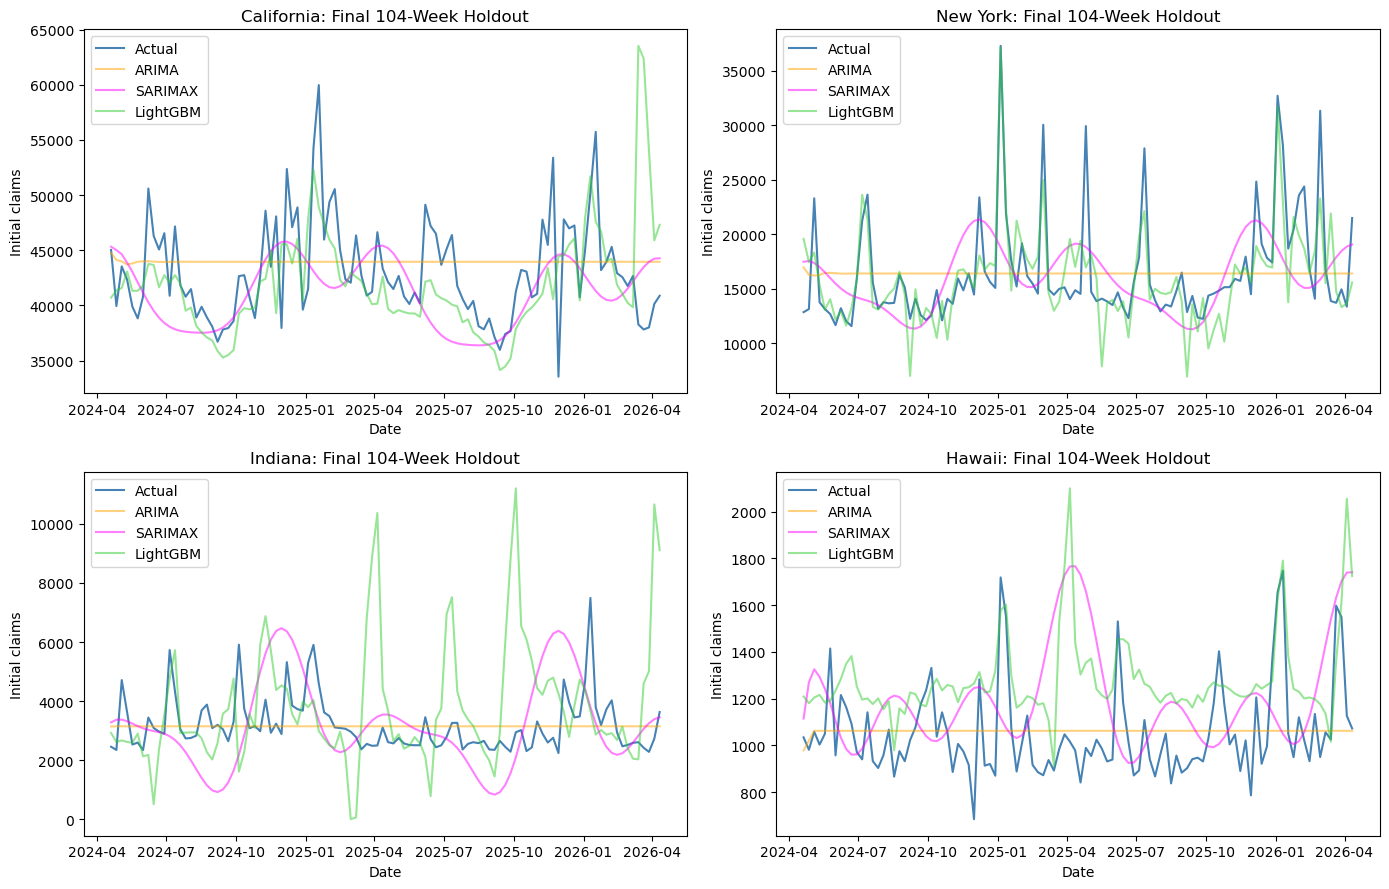

In [83]:
## Setting up a 2x2 grid for the four states
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
axes = axes.flatten()

## Plotting each state's holdout period
for ax, code in zip(axes, datasets):
    actual_df = arima_all_forecasts[code]
    sarimax_df = sarimax_all_forecasts[code]
    lgbm_df = lgbm_all_forecasts[code]

    ax.plot(actual_df["Date"], actual_df["Actual"], label="Actual", color="steelblue")
    ax.plot(actual_df["Date"], actual_df["Prediction"], label="ARIMA", color="orange", alpha=0.5)
    ax.plot(sarimax_df["Date"], sarimax_df["Prediction"], label="SARIMAX", color="magenta", alpha=0.5)
    ax.plot(lgbm_df["Date"], lgbm_df["Prediction"], label="LightGBM", color="limegreen", alpha=0.5)

    ax.set_title(f"{state_names[code]}: Final 104-Week Holdout")
    ax.set_xlabel("Date")
    ax.set_ylabel("Initial claims")
    ax.legend()

## The plot!
plt.tight_layout()
plt.show()

## **8. How We Interpreted the COVID Structural Break**

In the case of the COVID structural break, this was handled uniquely when it came to the baseline versus ML models. Mainly, the most basic ARIMA model serves as a simple time-series benchmark, not having any explicit COVID information/behaviors added. SARIMAX directly addresses the structural break, including the "covid_during" part for the acute pandemic shock and then "covid_after" for the period after the shock, additionally having controls for potential trends and weekly seasonality. Finally, the LightGBM model utilizes the same covid indicators as above for features, also including the use of lagged claims and rolling averages which allows the model to learn nonlinear relationships between recent claims history, seasonal timing, and the COVID-period indicators. By utilizing a recursive forecast design, the ML model is stopped from using actual holdout claims as lag inputs, meaning the comparison remains aligned with the multi-step ARIMA/SARIMAX forecasting setup!

## **9. Determining the Best Parameter Choices for the Econometric Forecasting Models**

Below, we have a table which touches directly on the selected ARIMA and SARIMAX specifications for each state. Here, our goal was to report both the model which had the lowest error but also interpret what certain parameter choices mean. Specifically, in the case of ARIMA and SARIMAX, the parameters have the same basic meaning: "p" controls how many autoregressive lags are included, "d" controls the degree of differencing used to remove non-stationary movement, and "q" controls the moving-average error correction. Overall, the main selection rule here is holdout RMSE on the same final 104-week test period. AIC and BIC are still reported because they help show model details, but the final comparison emphasizes predictive accuracy on "unseen" weeks.

**Code cell purpose:** This cell extracts the best ARIMA and SARIMAX parameter choices for every state and places them in one table. This matters because the table makes the selected `(p, d, q)` orders explicit and shows whether the more flexible SARIMAX setup improves holdout accuracy relative to the simpler ARIMA baseline.

In [73]:
## Storage for selected econometric parameter rows
selected_econometric_params = []

## Pulling best ARIMA and SARIMAX rows for each state
for code in datasets:
    arima_best = arima_all_results[code].dropna(subset=["RMSE"]).sort_values("RMSE").iloc[0]
    sarimax_best = sarimax_all_results[code].dropna(subset=["RMSE"]).sort_values("RMSE").iloc[0]

    selected_econometric_params.append({
        "StateCode": code,
        "State": state_names[code],
        "Model_Class": "ARIMA",
        "Order": f"({int(arima_best['p'])}, {int(arima_best['d'])}, {int(arima_best['q'])})",
        "AIC": arima_best["AIC"],
        "BIC": arima_best["BIC"],
        "Holdout_RMSE": arima_best["RMSE"]
    })

    selected_econometric_params.append({
        "StateCode": code,
        "State": state_names[code],
        "Model_Class": "SARIMAX",
        "Order": f"({int(sarimax_best['p'])}, {int(sarimax_best['d'])}, {int(sarimax_best['q'])})",
        "AIC": sarimax_best["AIC"],
        "BIC": sarimax_best["BIC"],
        "Holdout_RMSE": sarimax_best["RMSE"]
    })

## Final selected-parameter table
selected_econometric_params_df = pd.DataFrame(selected_econometric_params)
selected_econometric_params_df = selected_econometric_params_df.sort_values(["State", "Model_Class"])
display(selected_econometric_params_df.round(3))

,StateCode,State,Model_Class,Order,AIC,BIC,Holdout_RMSE
0,CAICLAIMS,California,ARIMA,"(4, 1, 0)","45,662.47","45,690.45","4,602.98"
1,CAICLAIMS,California,SARIMAX,"(2, 1, 2)","45,509.07","45,587.40","5,014.30"
6,HIICLAIMS,Hawaii,ARIMA,"(0, 1, 3)","33,855.56","33,878.03",197.68
7,HIICLAIMS,Hawaii,SARIMAX,"(4, 1, 1)","33,702.19","33,786.44",330.44
4,INICLAIMS,Indiana,ARIMA,"(1, 1, 0)","37,884.10","37,895.30",912.34
5,INICLAIMS,Indiana,SARIMAX,"(2, 1, 2)","37,644.90","37,723.23","1,522.12"
2,NYICLAIMS,New York,ARIMA,"(3, 1, 0)","42,397.54","42,419.93","4,938.98"
3,NYICLAIMS,New York,SARIMAX,"(1, 1, 2)","42,382.28","42,455.01","4,973.94"


Table above directly informs us about specific econometric parameter choices. Mainly, a lower value of "d" usually means the model can work with the level of claims after controlling for lag structure, while "d = 1" means the selected model relies on week-to-week changes rather than raw levels. Higher "p" values give the model more direct lag dependence, while higher "q" values let the model correct for recent forecast errors. SARIMAX uses the same order logic, but it also receives trend, seasonal Fourier terms, and COVID-period indicators, so its selected order should be interpreted as the remaining autoregressive structure after those controls are included!

## **10. Exploring the Near-Best ARIMA and SARIMAX Specifications**

Even though we have a table showcasing good models, the best model should not simply be deemed that which appears first. To avoid this issue, we have an output below which provides the top three best ARIMA/SARIMAX specifications per state, allowing us to have full robustness when checking models! Mainly, if there is extreme similarities in the RMSE values of top models, then broader modeling choice matters more than direct ordering of the models. However, if there are clearly major differences in RMSE, then order does matter for the models!

**Code cell purpose:** This cell displays the top three ARIMA and SARIMAX candidate specifications for each state. This matters because it helps justify whether the selected parameter choice is robust or whether several nearby specifications perform similarly.

In [74]:
## Storage for top candidate rows across both econometric model classes
top_econometric_candidates = []

## Collecting the top three ARIMA and SARIMAX models by holdout RMSE
for code in datasets:
    for model_class, results in [("ARIMA", arima_all_results[code]), ("SARIMAX", sarimax_all_results[code])]:
        top_rows = results.dropna(subset=["RMSE"]).sort_values("RMSE").head(3).reset_index(drop=True)
        for rank, row in top_rows.iterrows():
            top_econometric_candidates.append({
                "StateCode": code,
                "State": state_names[code],
                "Model_Class": model_class,
                "Rank": rank + 1,
                "Order": f"({int(row['p'])}, {int(row['d'])}, {int(row['q'])})",
                "Holdout_RMSE": row["RMSE"],
                "AIC": row["AIC"],
                "BIC": row["BIC"]
            })

## Displaying near-best candidates for interpretation
top_econometric_candidates_df = pd.DataFrame(top_econometric_candidates)
top_econometric_candidates_df = top_econometric_candidates_df.sort_values(["State", "Model_Class", "Rank"])
display(top_econometric_candidates_df.round(3))

,StateCode,State,Model_Class,Rank,Order,Holdout_RMSE,AIC,BIC
0,CAICLAIMS,California,ARIMA,1,"(4, 1, 0)","4,602.98","45,662.47","45,690.45"
1,CAICLAIMS,California,ARIMA,2,"(0, 1, 3)","4,681.73","45,644.79","45,667.18"
2,CAICLAIMS,California,ARIMA,3,"(0, 1, 2)","4,682.99","45,710.97","45,727.76"
3,CAICLAIMS,California,SARIMAX,1,"(2, 1, 2)","5,014.30","45,509.07","45,587.40"
4,CAICLAIMS,California,SARIMAX,2,"(2, 1, 3)","5,028.90","45,475.57","45,559.49"
5,CAICLAIMS,California,SARIMAX,3,"(3, 1, 2)","5,040.56","45,562.93","45,646.87"
18,HIICLAIMS,Hawaii,ARIMA,1,"(0, 1, 3)",197.68,"33,855.56","33,878.03"
19,HIICLAIMS,Hawaii,ARIMA,2,"(0, 1, 2)",197.80,"33,947.38","33,964.24"
20,HIICLAIMS,Hawaii,ARIMA,3,"(4, 1, 0)",198.03,"33,883.93","33,912.02"
21,HIICLAIMS,Hawaii,SARIMAX,1,"(4, 1, 1)",330.44,"33,702.19","33,786.44"


## **11. LightGBM Parameter Choices and Validation Logic**

LightGBM is selected differently from ARIMA/SARIMAX. Rather than choosing `(p, d, q)` orders, the model chooses hyperparameters which control the complexity of boosted decision trees. In our notebook, `n_estimators` controls the number of boosting rounds, `learning_rate` controls how aggressively each tree updates the prediction, `num_leaves` controls how flexible each tree can be, and `min_child_samples` regularizes the tree by requiring enough observations in each leaf.

The LightGBM grid is chosen using a time-ordered validation split inside the training period, NOT the final test/holdout period. This preserves the final 104 weeks/two-year [eriod as a fair test set shared across ARIMA, SARIMAX, and LightGBM!

**Code cell purpose:** This cell reports the selected LightGBM hyperparameters for every state and connects the validation score to the final holdout score. This matters because the ML model is tuned on a training-only validation window but evaluated on the same final holdout window as the econometric models. Ensuring consistency and effective testing.

In [75]:
## Storage for selected LightGBM hyperparameter rows
selected_lgbm_params = []

## Pulling selected LightGBM parameters and final holdout results
for code in datasets:
    best_valid = lgbm_all_results[code].dropna(subset=["Valid_RMSE"]).sort_values("Valid_RMSE").iloc[0]
    holdout_row = all_state_model_comparison.query("StateCode == @code and Model_Class == 'LightGBM'").iloc[0]

    selected_lgbm_params.append({
        "StateCode": code,
        "State": state_names[code],
        "n_estimators": int(best_valid["n_estimators"]),
        "learning_rate": float(best_valid["learning_rate"]),
        "num_leaves": int(best_valid["num_leaves"]),
        "min_child_samples": int(best_valid["min_child_samples"]),
        "Validation_RMSE": best_valid["Valid_RMSE"],
        "Holdout_RMSE": holdout_row["RMSE"],
        "Holdout_MAE": holdout_row["MAE"]
    })

## Final LightGBM parameter table
selected_lgbm_params_df = pd.DataFrame(selected_lgbm_params)
selected_lgbm_params_df = selected_lgbm_params_df.sort_values("State")
display(selected_lgbm_params_df.round(3))

,StateCode,State,n_estimators,learning_rate,num_leaves,min_child_samples,Validation_RMSE,Holdout_RMSE,Holdout_MAE
0,CAICLAIMS,California,250,0.03,15,20,"3,623.35","5,392.88","3,517.73"
3,HIICLAIMS,Hawaii,350,0.03,31,20,690.73,301.53,247.19
2,INICLAIMS,Indiana,350,0.03,31,20,"1,333.85","2,360.43","1,582.26"
1,NYICLAIMS,New York,350,0.05,31,30,"2,940.03","3,246.46","2,322.34"


In terms of interpretation here, LightGBM is considered a more flexible model as compared to the main structural model. This is because of the fact that, while ARIMA and SARIMAX impose explicit time-series structure, the LightGBM model instead learns nonlinear relationships from engineered predictors like lags, rolling means, seasonality, trend, and COVID indicators. In turn, if we see that LightGBM performs best, the interpretation is that nonlinear lag and seasonal patterns helped! But, if SARIMAX performs best, the interpretation is that a more structured time-series model with explicit COVID and seasonal controls generalized better (as compared to the baseline boring ARIMA model).

## **12. LightGBM Feature Importance Across States**

We wanted to increase the interpretability of our LightGBM model, hence the following chunk of code. Mainly, feature importance is not something like a causal estimate, but instead helps identify whether the model is relying mostly on recent lagged claims, longer-run rolling averages, seasonal timing, trend, or COVID-period indicators. This is useful for comparing the ML process against the econometric process, as the econometric models specify lag and seasonal structure directly, while the LightGBM ML model learns which engineered predictors are most useful.

**Code cell purpose:** Cell below refits each state's selected LightGBM model on the training period and reports the most important predictors. This matters because here we delve into model logic and variable selection, and feature importance gives us a more-concrete way to explain what the ML model used most heavily!

In [76]:
## Storage for feature-importance rows
lgbm_feature_importance = []

## Refit selected LightGBM models to inspect feature importance
for code in datasets:
    df, y, dates, train_end_state = get_state_split(code, all_state_test_horizon)
    test_start_date = dates.iloc[train_end_state]
    ml_frame = make_lgbm_frame(df, lgbm_lags, lgbm_windows)
    train_frame = ml_frame.loc[ml_frame["Date"] < test_start_date].reset_index(drop=True)
    features = ml_feature_columns(train_frame)
    best_valid = lgbm_all_results[code].dropna(subset=["Valid_RMSE"]).sort_values("Valid_RMSE").iloc[0]
    best_params = clean_lgbm_params(best_valid)
    model = LGBMRegressor(objective="regression", random_state=148, verbosity=-1, **best_params)
    model.fit(train_frame[features], train_frame["Claims"])

    for feature, importance in zip(features, model.feature_importances_):
        lgbm_feature_importance.append({"StateCode": code, "State": state_names[code], "Feature": feature, "Importance": importance})

## Displaying the top predictors for each state
top_lgbm_features_df = pd.DataFrame(lgbm_feature_importance)
top_lgbm_features_df = top_lgbm_features_df.sort_values(["State", "Importance"], ascending=[True, False])
top_lgbm_features_df = top_lgbm_features_df.groupby("State", as_index=False).head(8)
display(top_lgbm_features_df.reset_index(drop=True))

,StateCode,State,Feature,Importance
0,CAICLAIMS,California,lag_1,504
1,CAICLAIMS,California,week,396
2,CAICLAIMS,California,lag_52,368
3,CAICLAIMS,California,lag_26,361
4,CAICLAIMS,California,roll_mean_52,249
5,CAICLAIMS,California,lag_4,245
6,CAICLAIMS,California,week_cos,238
7,CAICLAIMS,California,roll_mean_4,235
8,HIICLAIMS,Hawaii,lag_1,1609
9,HIICLAIMS,Hawaii,trend,957


## **13. Final Model Choice and Modeling Logic Comparison**

For our final comparison of models, we decided that this should be discussed in a state-by-state manner as we have unequal dynamics in the labor markets of California, New York, Indiana, and Hawaii. Here, the best model is chosen through the measure of holdout RMSE, since the main goal of our work here was the forecasting of weekly initial claims. MAE, as above, is a secondary metric provided which is included as it's easier to read as the "average absolute forecasting error" in claims. Generally, our logic is that ARIMA is the cleanest baseline since it only uses past claims values. SARIMAX extends that baseline by adding trend, seasonal Fourier controls, and COVID structural-break indicators. Finally, LightGBM is the ML comparison as it turns the problem into supervised learning with lag, rolling, calendar, trend, and COVID features. Overall, we have a fair comparison as all models are evaluated on the exact same two-year holdout period as a test group.

**Code cell purpose:** Cell below creates one final recommendation table that combines the best model for each state with the selected parameter or hyperparameter details. This matters because it gives us a concise table for stating which model should be emphasized and why!

In [77]:
## Storage for final recommendation rows
final_recommendation_rows = []

## Combining best model choices with relevant parameter details
for _, row in best_model_by_state.iterrows():
    code = row["StateCode"]
    model_class = row["Model_Class"]
    detail = row["Model"]

    if model_class == "LightGBM":
        params = selected_lgbm_params_df.query("StateCode == @code").iloc[0]
        detail = f"LightGBM: leaves={params['num_leaves']}, lr={params['learning_rate']}, trees={params['n_estimators']}"

    final_recommendation_rows.append({
        "StateCode": code,
        "State": row["State"],
        "Recommended_Model": model_class,
        "Selected_Details": detail,
        "Holdout_RMSE": row["RMSE"],
        "Holdout_MAE": row["MAE"],
        "Reason": "Lowest final-104-week holdout RMSE among ARIMA, SARIMAX, and LightGBM"
    })

## Displaying final recommendations
final_model_recommendations_df = pd.DataFrame(final_recommendation_rows)
final_model_recommendations_df = final_model_recommendations_df.sort_values("State")
display(final_model_recommendations_df.round(3))

,StateCode,State,Recommended_Model,Selected_Details,Holdout_RMSE,Holdout_MAE,Reason
0,CAICLAIMS,California,ARIMA,"ARIMA(4, 1, 0)","4,602.98","3,760.82",Lowest final-104-week holdout RMSE among ARIMA...
1,HIICLAIMS,Hawaii,ARIMA,"ARIMA(0, 1, 3)",197.68,142.40,Lowest final-104-week holdout RMSE among ARIMA...
2,INICLAIMS,Indiana,ARIMA,"ARIMA(1, 1, 0)",912.34,641.19,Lowest final-104-week holdout RMSE among ARIMA...
3,NYICLAIMS,New York,LightGBM,"LightGBM: leaves=31, lr=0.05, trees=350","3,246.46","2,322.34",Lowest final-104-week holdout RMSE among ARIMA...


To summarize general work, ARIMA is the benchmark that tests whether past claims alone are enough. As a progression, SARIMAX is the structured econometric model that keeps the ARIMA logic while adding seasonality and COVID controls. Finally, LightGBM is our ML comparison which can capture nonlinear patterns in lags, rolling averages, seasonality, trend, and COVID features. Holistically, the strongest final claim of "best model" should be based on the state-by-state holdout RMSE table rather than on in-sample fit alone. Now, for COVID, we handled the break in two ways. The basic ARIMA benchmark does not receive COVID variables, showing how a simple time-series model performs without explicit structural-break controls. SARIMAX and LightGBM both include `covid_during` and `covid_after`, allowing the models to treat the acute pandemic period and post-pandemic period differently from the pre-pandemic period while still using the same observations. This is important as deleting COVID would remove economically meaningful labor-market stress, while ignoring it completely could make the models confuse an extraordinary shock with normal weekly dynamics.